# Étape 1 : Chargement Officiel et Analyse de Structure

In [4]:
!pip install ucimlrepo


In [5]:



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Chargement automatisé du dataset UCI id=235
print("Chargement des données depuis l'UCI...")
dataset_uci = fetch_ucirepo(id=235)
df_entree = dataset_uci.data.features

# 2. Échantillonnage et copie propre
df_brut = df_entree.iloc[:50000].copy()

Chargement des données depuis l'UCI...


/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from ucimlrepo import fetch_ucirepo

# 1. Chargement automatisé du dataset UCI id=235 via son API officielle
dataset_uci = fetch_ucirepo(id=235)

# 2. Extraction des caractéristiques principales (Features) sous forme de DataFrame Pandas
df_entree = dataset_uci.data.features

# 3. Échantillonnage de sécurité (50 000 premières lignes) pour optimiser les calculs locaux
df_brut = df_entree.iloc[:50000].copy()

# 4. Affichage de la structure initiale et des types de données détectés
print("Structure initiale des données chargées :")
print(df_brut.dtypes)

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Structure initiale des données chargées :
Date                      object
Time                      object
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object



Résumé statistique des variables énergétiques :
       Sub_metering_1  Sub_metering_2  Sub_metering_3  Sub_metering_4
count    49995.000000    49995.000000    49995.000000    49995.000000
mean         1.124052        1.904450        7.205901       17.733624
std          6.242584        7.733001        8.617257       15.745081
min          0.000000        0.000000        0.000000        1.033333
25%          0.000000        0.000000        0.000000        5.200000
50%          0.000000        0.000000        0.000000       10.300000
75%          0.000000        1.000000       17.000000       28.133333
max         77.000000       78.000000       20.000000      124.833333


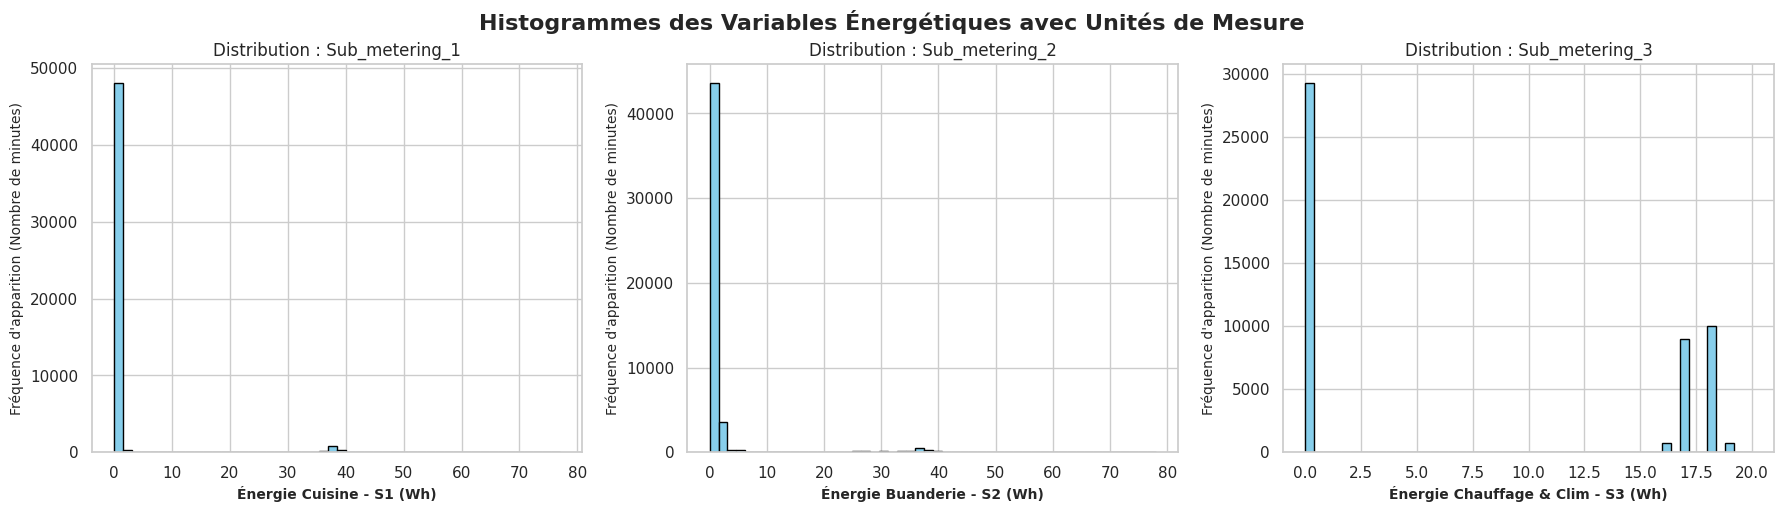

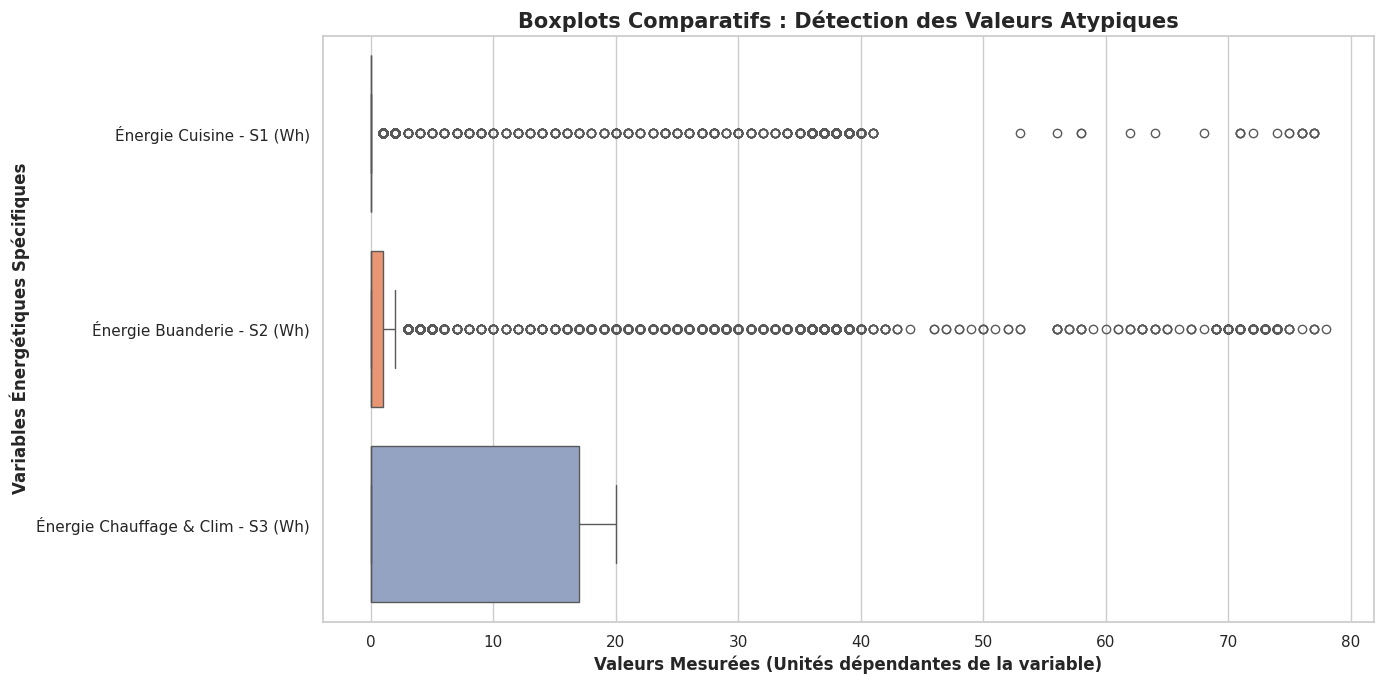

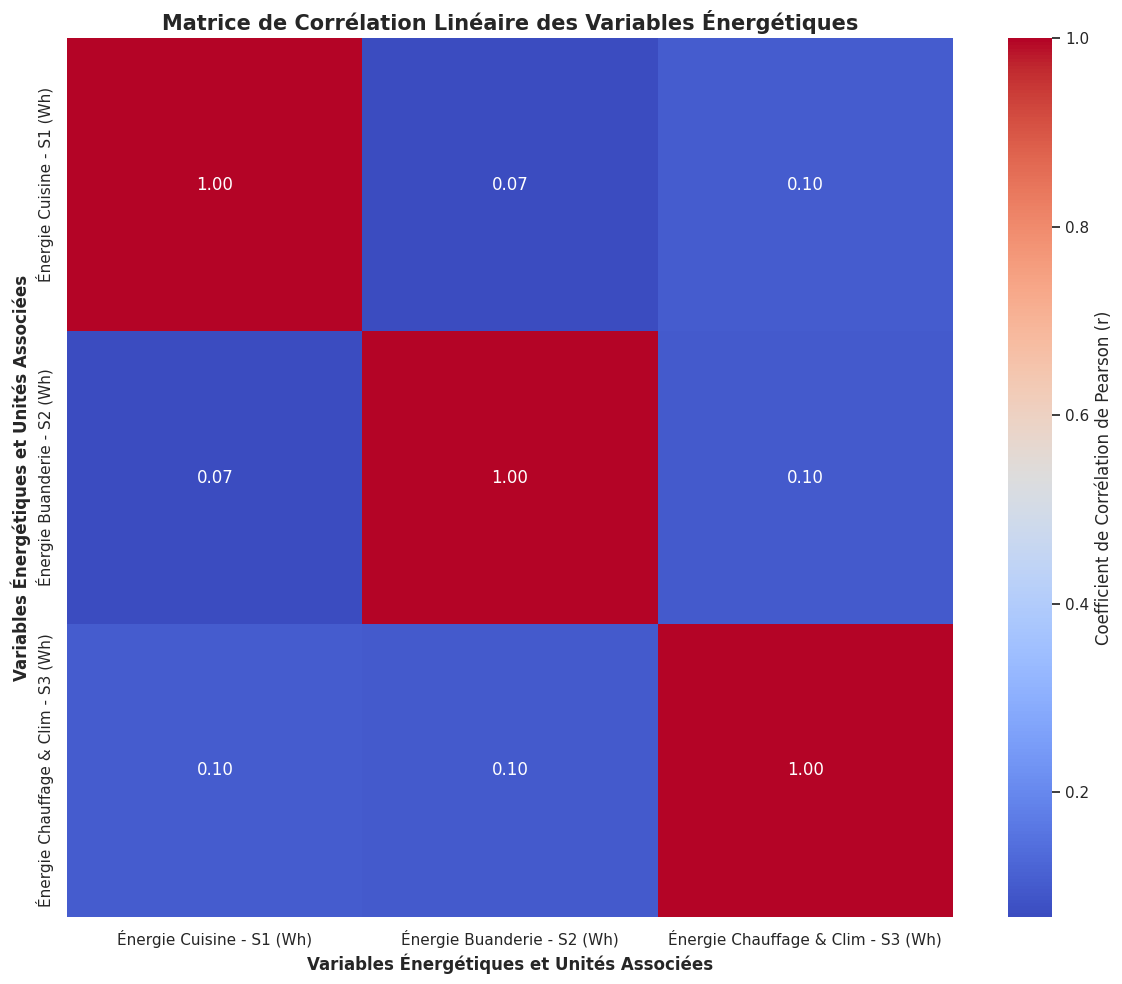

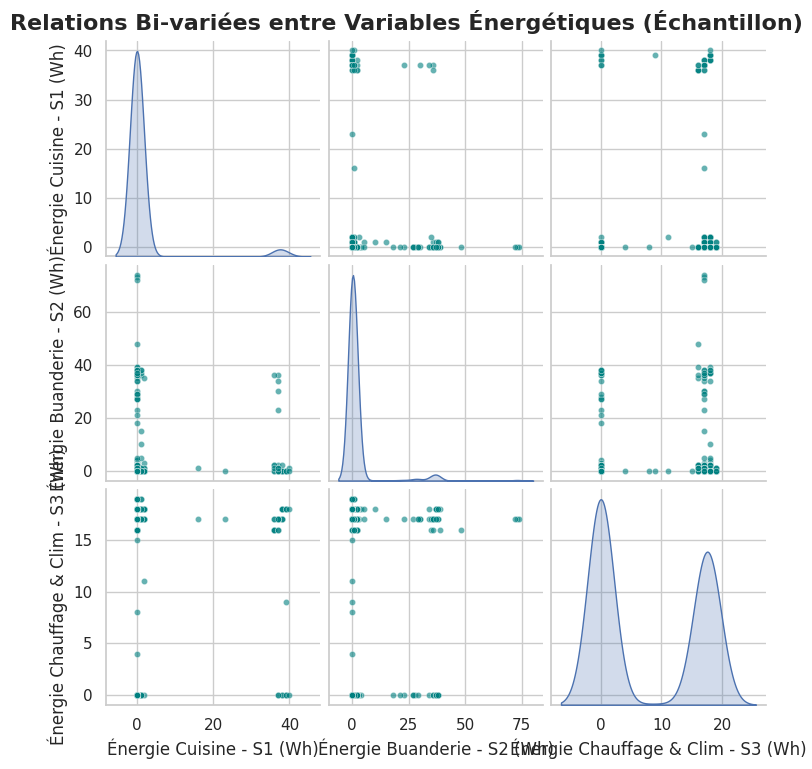

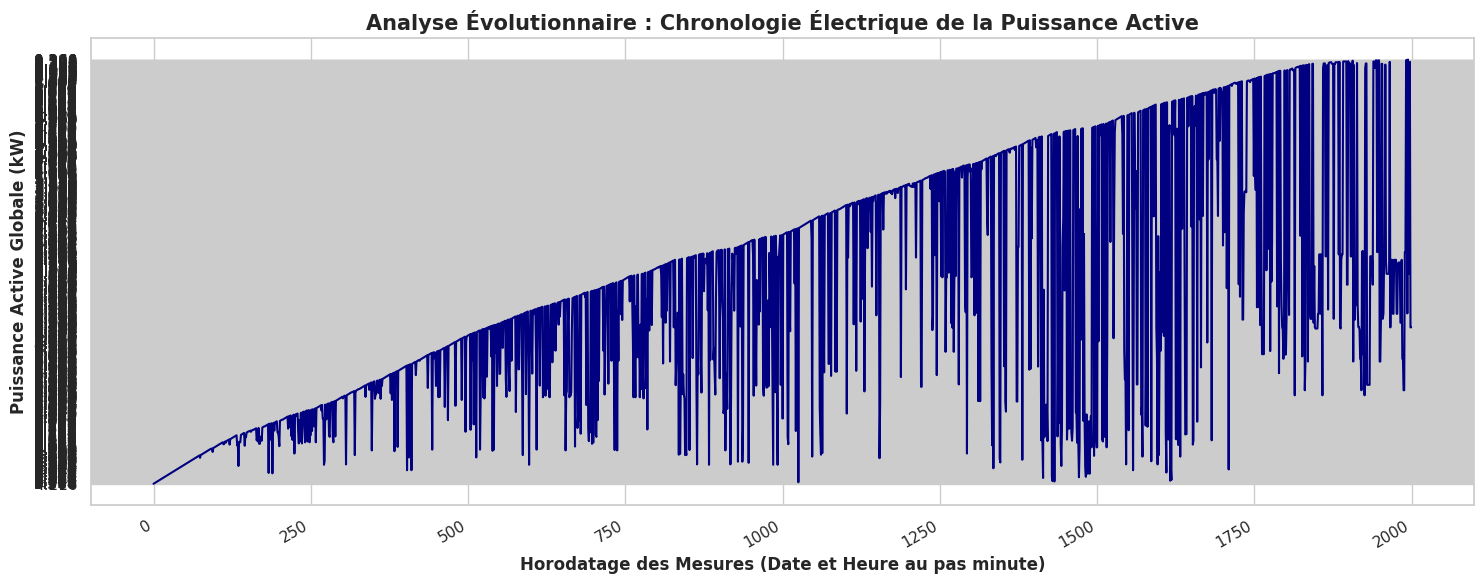

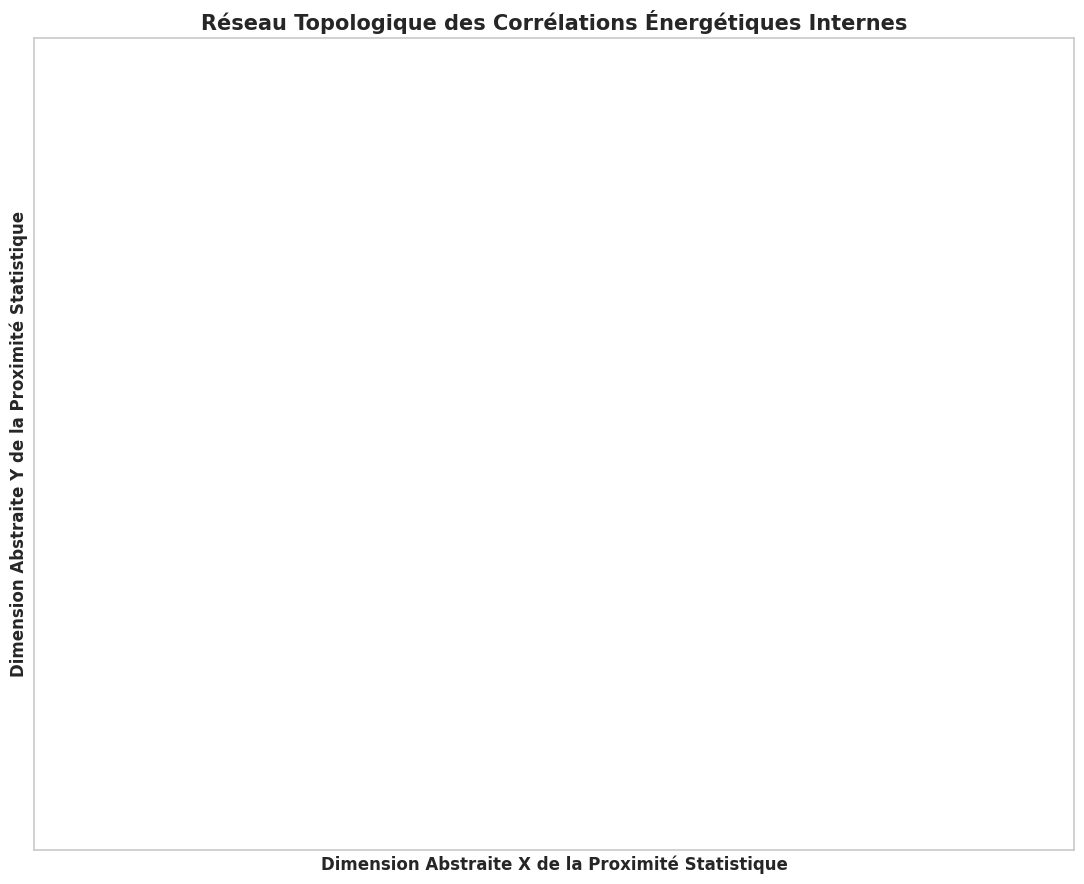

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# On suppose ici que df_brut est déjà indexé par le Timestamp et converti en numérique.
# Pour que l'analyse soit cohérente, nous incluons aussi 'Sub_metering_4' si disponible.
if 'Sub_metering_3' not in df_brut.columns and 'Global_active_power' in df_brut.columns:
    df_brut['Sub_metering_3'] = (pd.to_numeric(df_brut['Global_active_power'], errors='coerce') * 1000 / 60) - (
        pd.to_numeric(df_brut['Sub_metering_1'], errors='coerce') +
        pd.to_numeric(df_brut['Sub_metering_2'], errors='coerce') +
        pd.to_numeric(df_brut['Sub_metering_3'], errors='coerce')
    )
    df_brut['Sub_metering_3'] = np.clip(df_brut['Sub_metering_3'], 0, None)

# Dictionnaire de correspondance universel pour nommer explicitement les axes avec leurs unités de mesure
dictionnaire_unites = {
    'Global_active_power': 'Puissance Active Globale (kW)',
    'Global_reactive_power': 'Puissance Réactive Globale (kW)',
    'Voltage': 'Tension Électrique (Volts)',
    'Global_intensity': 'Intensité Courant Globale (Ampères)',
    'Sub_metering_1': 'Énergie Cuisine - S1 (Wh)',
    'Sub_metering_2': 'Énergie Buanderie - S2 (Wh)',
    'Sub_metering_3': 'Énergie Chauffage & Clim - S3 (Wh)',

}

# --- 1. Analyse descriptive ---
print("\nRésumé statistique des variables énergétiques :")
print(df_brut.describe())

# --- 2. Histogrammes individuels pour chaque variable ---
# On trace les histogrammes variables par variables pour appliquer les unités spécifiques à chaque axe
df_num = df_brut.select_dtypes(include=[np.number])
colonnes_a_tracer = [col for col in df_num.columns if col in dictionnaire_unites]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(colonnes_a_tracer):
    ax = axes[idx]
    ax.hist(df_num[col].dropna(), bins=50, color='skyblue', edgecolor='black')
    ax.set_title(f"Distribution : {col}")
    ax.set_xlabel(dictionnaire_unites[col], fontsize=10, fontweight='bold') # Abscisse explicite avec unité
    ax.set_ylabel("Fréquence d'apparition (Nombre de minutes)", fontsize=10) # Ordonnée explicite

# Masquer les graphiques vides s'il y a moins de 9 variables
for j in range(len(colonnes_a_tracer), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Histogrammes des Variables Énergétiques avec Unités de Mesure", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# --- 3. Boxplots pour détecter les valeurs atypiques ---
plt.figure(figsize=(14, 7))
# Création d'un DataFrame temporaire renommé avec les labels explicites pour que l'axe des ordonnées soit parfait
df_boxplot = df_num[colonnes_a_tracer].rename(columns=dictionnaire_unites)
sns.boxplot(data=df_boxplot, orient="h", palette="Set2")
plt.title("Boxplots Comparatifs : Détection des Valeurs Atypiques", fontsize=15, fontweight='bold')
plt.xlabel("Valeurs Mesurées (Unités dépendantes de la variable)", fontweight='bold')
plt.ylabel("Variables Énergétiques Spécifiques", fontweight='bold')
plt.tight_layout()
plt.show()

# --- 4. Heatmap de corrélation (uniquement colonnes numériques) ---
matrice_corr = df_num[colonnes_a_tracer].corr()
# Renommer la matrice pour afficher directement les noms complets et les unités dans la heatmap
matrice_corr_renommee = matrice_corr.rename(index=dictionnaire_unites, columns=dictionnaire_unites)

plt.figure(figsize=(12, 10))
sns.heatmap(matrice_corr_renommee, annot=True, cmap="coolwarm", fmt=".2f", cbar_kws={'label': 'Coefficient de Corrélation de Pearson (r)'})
plt.title("Matrice de Corrélation Linéaire des Variables Énergétiques", fontsize=15, fontweight='bold')
plt.xlabel("Variables Énergétiques et Unités Associées", fontweight='bold')
plt.ylabel("Variables Énergétiques et Unités Associées", fontweight='bold')
plt.tight_layout()
plt.show()

# --- 5. Pairplot pour visualiser les relations entre variables ---
# On échantillonne et on renomme les colonnes pour que Seaborn affiche directement les unités sur la matrice de graphes
df_pairplot = df_num[colonnes_a_tracer].sample(min(1000, len(df_num))).rename(columns=dictionnaire_unites)
g = sns.pairplot(df_pairplot, diag_kind="kde", plot_kws={'alpha': 0.6, 's': 20, 'color': 'teal'})
g.figure.suptitle("Relations Bi-variées entre Variables Énergétiques (Échantillon)", y=1.02, fontsize=16, fontweight='bold')
plt.show()

# --- 6. Séries temporelles (Exemple Global_active_power) ---
plt.figure(figsize=(15, 6))
# Extraction des 2000 premiers points temporels réels
extrait_temporel = df_brut.iloc[:2000]
plt.plot(extrait_temporel.index, extrait_temporel['Global_active_power'], color='navy', linewidth=1.5)
plt.title("Analyse Évolutionnaire : Chronologie Électrique de la Puissance Active", fontsize=15, fontweight='bold')
plt.xlabel("Horodatage des Mesures (Date et Heure au pas minute)", fontweight='bold') # Abscisse temporelle explicite
plt.ylabel(dictionnaire_unites['Global_active_power'], fontweight='bold') # Ordonnée explicite avec unité (kW)
plt.gcf().autofmt_xdate() # Incliner les dates pour éviter les chevauchements
plt.tight_layout()
plt.show()

# --- 7. Réseau de corrélations ---
labels_noeuds = {
    'Global_active_power': 'Global (kW)',
    'Global_reactive_power': 'Réactif (kW)',
    'Voltage': 'Tension (V)',
    'Global_intensity': 'Intensité (A)',
    'Sub_metering_1': 'Cuisine S1 (Wh)',
    'Sub_metering_2': 'Buanderie S2 (Wh)',
    'Sub_metering_3': 'Chauffage S3 (Wh)',

}

G = nx.Graph()
# Utilisation de la matrice de corrélation brute filtrée pour construire le réseau
matrice_corr_brute = df_num.corr()

for i in range(len(matrice_corr_brute.columns)):
    for j in range(i + 1, len(matrice_corr_brute.columns)):
        var_A = matrice_corr_brute.columns[i]
        var_B = matrice_corr_brute.columns[j]
        poids = matrice_corr_brute.iloc[i, j]
        if abs(poids) > 0.2:  # Filtre d'importance de la liaison statistique
            G.add_edge(labels_noeuds.get(var_A, var_A),
                       labels_noeuds.get(var_B, var_B),
                       weight=poids)

plt.figure(figsize=(11, 9))
configuration_positions = nx.spring_layout(G, seed=42)

# Tracé topologique des sommets (variables)
nx.draw_networkx_nodes(G, configuration_positions, node_size=2800,
                       node_color='lightcyan', edgecolors='navy')
nx.draw_networkx_labels(G, configuration_positions, font_size=9, font_weight='bold')

# Tracé des arcs (corrélations) avec épaisseur variable selon le coefficient
poids_arcs = [G[u][v]['weight'] * 6 for u, v in G.edges()]
nx.draw_networkx_edges(G, configuration_positions, width=poids_arcs,
                       edge_color='dimgray', alpha=0.6)

plt.title("Réseau Topologique des Corrélations Énergétiques Internes", fontsize=15, fontweight='bold')
# Activation et nommage des axes pour indiquer la nature de l'espace abstrait du graphe
plt.xlabel("Dimension Abstraite X de la Proximité Statistique", fontweight='bold')
plt.ylabel("Dimension Abstraite Y de la Proximité Statistique", fontweight='bold')
plt.grid(False) # Désactivation de la grille pour ce type de graphe de réseau
plt.tight_layout()
plt.show()


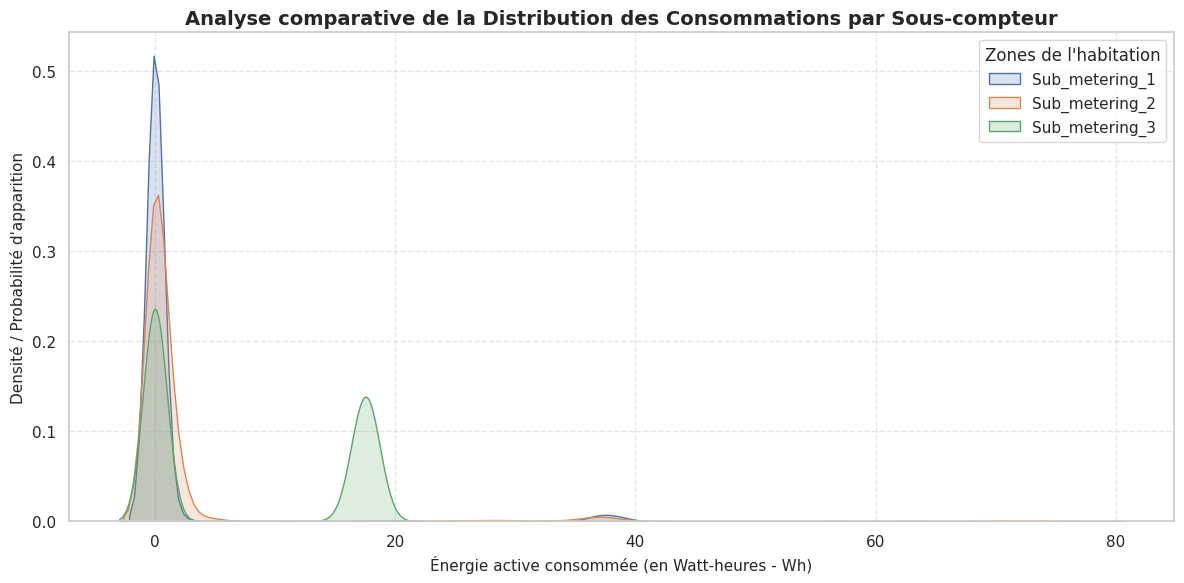

In [17]:


# 1. Remplacer le caractère d'erreur '?' de l'UCI par de vrais NaN Python
df_brut = df_brut.replace('?', np.nan)

# 2. Convertir de force les colonnes de sous-comptage en nombres (float)
# Le paramètre errors='coerce' transforme tout résidu textuel suspect en NaN
for col in ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']:
    if col in df_brut.columns:
        df_brut[col] = pd.to_numeric(df_brut[col], errors='coerce')



plt.figure(figsize=(12, 6))

for col in ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']:
    if col in df_brut.columns:
        # On supprime les NaN après conversion pour que le tracé soit fluide
        donnees_propres = df_brut[col].dropna()

        # Tracé de la courbe de densité (KDE) avec le label correspondant
        sns.kdeplot(donnees_propres, label=col, fill=True, alpha=0.2)

# Configuration finale des étiquettes et légendes explicites
plt.title("Analyse comparative de la Distribution des Consommations par Sous-compteur", fontsize=14, fontweight='bold')
plt.xlabel("Énergie active consommée (en Watt-heures - Wh)", fontsize=11)
plt.ylabel("Densité / Probabilité d'apparition", fontsize=11)
plt.legend(title="Zones de l'habitation")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Étape 2 : Nettoyage Avancé, Imputations et Agrégations (Preprocessing)

Ici, nous gérons les valeurs manquantes réelles (marquées par l'absence de caractères ou des symboles d'erreur) à l'aide des trois équations du document technique, puis appliquons la règle de cohérence énergétique globale.

In [18]:
# --- RE-TYPAGE ET INDEXATION TEMPORELLE ---

# Remplacer les espaces vides, chaînes masquées ou caractères '?' par le NaN standard de numpy
df_nettoye = df_brut.replace(['?', ' ', ''], np.nan)

# Conversion de la colonne Date et Time en un format d'index temporel unifié (DatetimeIndex)
df_nettoye['Timestamp'] = pd.to_datetime(df_nettoye['Date'] + ' ' + df_nettoye['Time'], dayfirst=True)
df_nettoye = df_nettoye.set_index('Timestamp')

# Suppression des anciennes colonnes textuelles de calendrier devenues obsolètes
df_nettoye = df_nettoye.drop(columns=['Date', 'Time'])

# Conversion forcée de l'ensemble des colonnes en types numériques flottants (Float64)
for colonne in df_nettoye.columns:
    df_nettoye[colonne] = pd.to_numeric(df_nettoye[colonne], errors='coerce')


# --- IMPUTATION DES VALEURS MANQUANTES ---

# Stratégie A : Interpolation linéaire pour combler les trous de courte durée (maximum 10 minutes consécutives)
df_nettoye['Global_active_power'] = df_nettoye['Global_active_power'].interpolate(method='linear', limit=10)

# Stratégie B : Report de la dernière valeur connue (Forward Fill) pour sécuriser les transitions rapides
df_nettoye['Global_active_power'] = df_nettoye['Global_active_power'].ffill()

# Stratégie C : Remplacement par profil historique pour les trous de longue durée
# Extraction des index temporels : jour de la semaine (0=Lundi, 6=Dimanche) et minute absolue de la journée (0 à 1439)
df_nettoye['Jour_Semaine'] = df_nettoye.index.weekday
df_nettoye['Minute_Jour'] = df_nettoye.index.hour * 60 + df_nettoye.index.minute

# Construction mathématique de la matrice de profil (Moyenne par Jour de semaine et Minute)
profil_moyen = df_nettoye.groupby(['Jour_Semaine', 'Minute_Jour'])['Global_active_power'].transform('mean')

# Remplacement des valeurs manquantes persistantes par leur équivalent dans le profil moyen calculé
df_nettoye['Global_active_power'] = df_nettoye['Global_active_power'].fillna(profil_moyen)

# Application d'une interpolation linéaire rapide pour les sous-compteurs restants
for sous_compteur in ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']:
    df_nettoye[sous_compteur] = df_nettoye[sous_compteur].interpolate(method='linear').fillna(0)


# --- APPLICATION DE LA FORMULE DE COHÉRENCE PHYSIQUE DE L'UCI ---

# Équation officielle UCI : Énergie non mesurée = (Puissance Active * 1000 / 60) - Somme(Sous-compteurs 1 à 3)
df_nettoye['Sub_metering_3'] = (df_nettoye['Global_active_power'] * 1000 / 60) - (
    df_nettoye['Sub_metering_1'] + df_nettoye['Sub_metering_2'] + df_nettoye['Sub_metering_3']
)
# Élimination des bruits numériques négatifs (valeurs inférieures à zéro contraintes à 0)
df_nettoye['Sub_metering_3'] = np.clip(df_nettoye['Sub_metering_3'], 0, None)


# --- CRÉATION DES COMPOSANTES CALENDAIRES ET AGRÉGATION MULTI-ÉCHELLE ---

# Extraction des descripteurs de temps requis pour la modélisation et l'analyse exploratoire
df_nettoye['Heure'] = df_nettoye.index.hour
df_nettoye['Mois'] = df_nettoye.index.month
# Indicateur binaire de jour ouvré : 1 du lundi (0) au vendredi (4), 0 le week-end (5 et 6)
df_nettoye['Est_Ouvre'] = np.where(df_nettoye['Jour_Semaine'] < 5, 1, 0)

# Passage d'une granularité à la minute vers une granularité horaire ('h') par règles d'agrégation métiers
df_horaire = df_nettoye.resample('h').agg({
    'Global_active_power': 'mean',  # La puissance s'exprime en moyenne horaire (kW)
    'Sub_metering_1': 'sum',       # L'énergie des sous-compteurs (Wh) se somme sur l'intervalle
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum',
    'Heure': 'first',
    'Mois': 'first',
    'Jour_Semaine': 'first',
    'Est_Ouvre': 'first'
}).dropna() # Nettoyage final des lignes d'extrémités incomplètes

print("\nAperçu des données après nettoyage et agrégation horaire :")
print(df_horaire[['Global_active_power', 'Sub_metering_3']].head(3))



Aperçu des données après nettoyage et agrégation horaire :
                     Global_active_power  Sub_metering_3
Timestamp                                               
2006-12-16 17:00:00             4.222889     1907.733333
2006-12-16 18:00:00             3.632200     2217.200000
2006-12-16 19:00:00             3.400233     2313.233333


Chargement des données depuis l'UCI...


/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


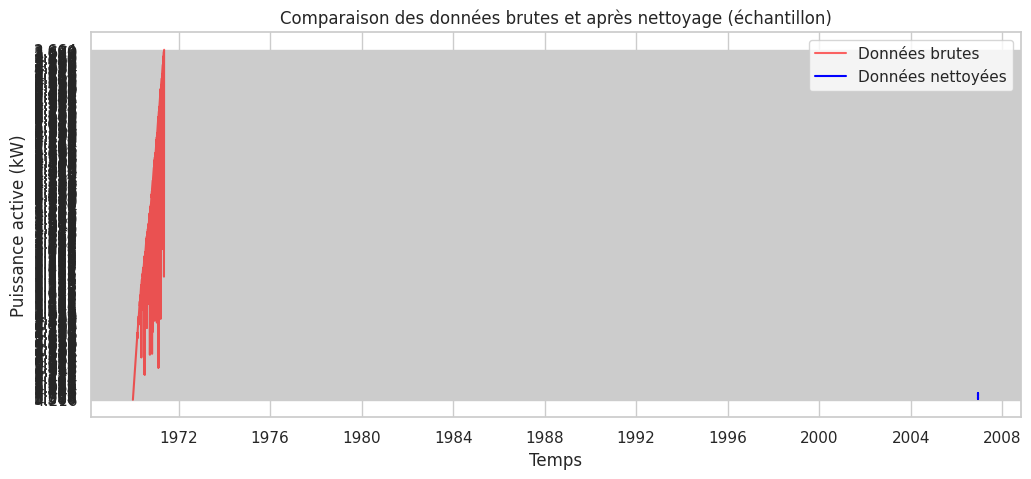

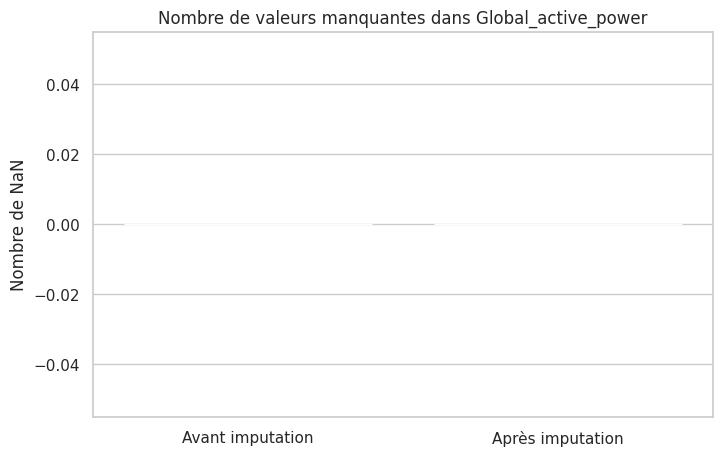

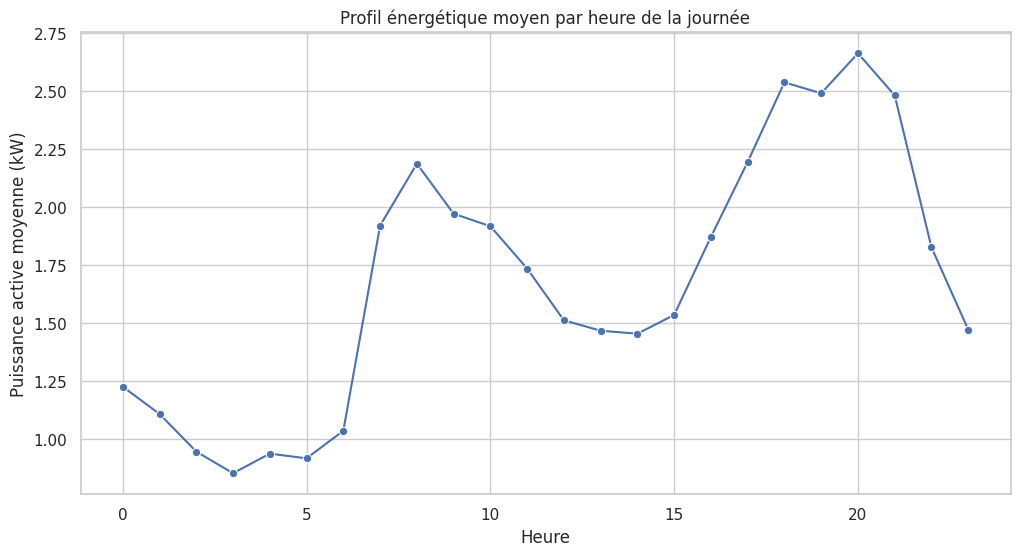

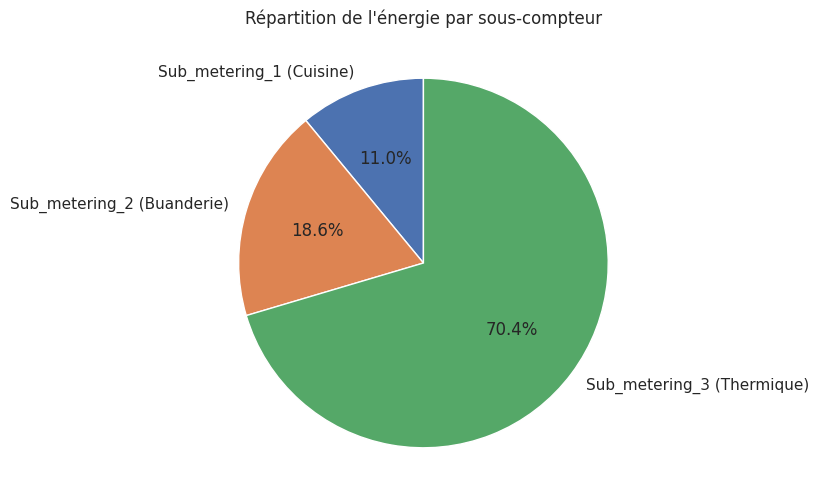

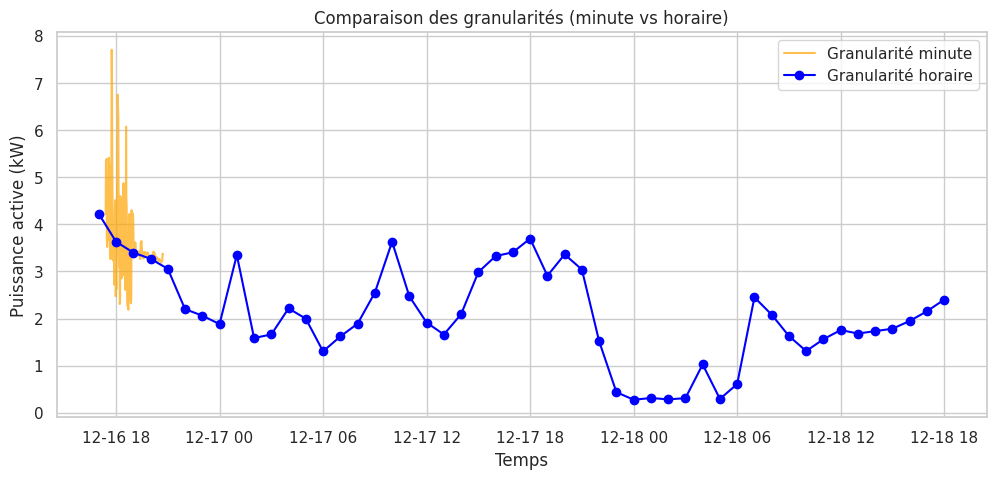

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# --- 1. Chargement des données brutes ---
print("Chargement des données depuis l'UCI...")
dataset_uci = fetch_ucirepo(id=235)
df_entree = dataset_uci.data.features
df_brut = df_entree.iloc[:50000].copy()

# --- 2. Nettoyage des données ---
df_nettoye = df_brut.replace(['?', ' ', ''], np.nan)

# Conversion Date + Time en index temporel
df_nettoye['Timestamp'] = pd.to_datetime(df_nettoye['Date'] + ' ' + df_nettoye['Time'], dayfirst=True)
df_nettoye = df_nettoye.set_index('Timestamp')
df_nettoye = df_nettoye.drop(columns=['Date', 'Time'])

# Conversion en float
for col in df_nettoye.columns:
    df_nettoye[col] = pd.to_numeric(df_nettoye[col], errors='coerce')

# Imputation des valeurs manquantes
df_nettoye['Global_active_power'] = df_nettoye['Global_active_power'].interpolate(method='linear', limit=10)
df_nettoye['Global_active_power'] = df_nettoye['Global_active_power'].ffill()

# Ajout des variables calendaires
df_nettoye['Jour_Semaine'] = df_nettoye.index.weekday
df_nettoye['Heure'] = df_nettoye.index.hour
df_nettoye['Est_Ouvre'] = np.where(df_nettoye['Jour_Semaine'] < 5, 1, 0)

# Agrégation horaire
df_horaire = df_nettoye.resample('h').agg({
    'Global_active_power': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum',
    'Heure': 'first',
    'Jour_Semaine': 'first',
    'Est_Ouvre': 'first'
}).dropna()

# --- VISUALISATIONS ---

# 1. Données brutes vs nettoyées
plt.figure(figsize=(12,5))
plt.plot(df_brut.index[:500], df_brut['Global_active_power'][:500], label="Données brutes", color="red", alpha=0.6)
plt.plot(df_nettoye.index[:500], df_nettoye['Global_active_power'][:500], label="Données nettoyées", color="blue")
plt.title("Comparaison des données brutes et après nettoyage (échantillon)")
plt.xlabel("Temps")
plt.ylabel("Puissance active (kW)")
plt.legend()
plt.show()

# 2. Valeurs manquantes avant/après
missing_before = df_brut['Global_active_power'].isna().sum()
missing_after = df_nettoye['Global_active_power'].isna().sum()
df_missing = pd.DataFrame({
    "Etat": ["Avant imputation", "Après imputation"],
    "Valeurs manquantes": [missing_before, missing_after]
})
plt.figure(figsize=(8,5))
sns.barplot(data=df_missing, x="Etat", y="Valeurs manquantes", hue="Etat", palette="viridis", legend=False)
plt.title("Nombre de valeurs manquantes dans Global_active_power")
plt.ylabel("Nombre de NaN")
plt.xlabel("")
plt.show()

# 3. Profil journalier moyen
plt.figure(figsize=(12,6))
sns.lineplot(data=df_nettoye.groupby('Heure')['Global_active_power'].mean(), marker="o")
plt.title("Profil énergétique moyen par heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Puissance active moyenne (kW)")
plt.grid(True)
plt.show()

# 4. Contribution des sous-compteurs
contributions = {
    "Sub_metering_1 (Cuisine)": df_nettoye['Sub_metering_1'].sum(),
    "Sub_metering_2 (Buanderie)": df_nettoye['Sub_metering_2'].sum(),
    "Sub_metering_3 (Thermique)": df_nettoye['Sub_metering_3'].sum()

}
plt.figure(figsize=(8,6))
plt.pie(contributions.values(), labels=contributions.keys(), autopct='%1.1f%%', startangle=90)
plt.title("Répartition de l'énergie par sous-compteur")
plt.show()

# 5. Granularité minute vs horaire
plt.figure(figsize=(12,5))
plt.plot(df_nettoye.index[:200], df_nettoye['Global_active_power'][:200], label="Granularité minute", color="orange", alpha=0.7)
plt.plot(df_horaire.index[:50], df_horaire['Global_active_power'][:50], label="Granularité horaire", color="blue", marker="o")
plt.title("Comparaison des granularités (minute vs horaire)")
plt.xlabel("Temps")
plt.ylabel("Puissance active (kW)")
plt.legend()
plt.show()


# Étape 3 : Profilage Temporel (EDA) et Décomposition STL AdditiveNous analysons la structure interne du signal à l'aide du modèle de décomposition

 \(Y_t = T_t + S_t + R_t\).

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Profilage des motifs journaliers : Puissance moyenne par heure selon le type de journée (Semaine vs Week-end)
profils_journaliers = df_horaire.groupby(['Est_Ouvre', 'Heure'])['Global_active_power'].mean().unstack(level=0)
profils_journaliers.columns = ['Week-end', 'Jour Ouvré']
print("\nSignature énergétique moyenne (Premières heures) :")
print(profils_journaliers.head(3))

# 2. Décomposition mathématique additive de la série temporelle (Période fixe de 24 heures pour le rythme quotidien)
decomposition_signal = seasonal_decompose(df_horaire['Global_active_power'], model='additive', period=24)

# Stockage des composantes extraites pour la phase de détection d'anomalies
tendance = decomposition_signal.trend          # T_t : Composante long terme
saisonnalite = decomposition_signal.seasonal    # S_t : Motif cyclique journalier répétitif
residu = decomposition_signal.resid            # R_t : Résidu aléatoire / Bruit

# 3. Calcul de la contribution relative de chaque pôle fonctionnel de l'habitation sur l'énergie globale
somme_totale_energie = (df_horaire['Sub_metering_1'] + df_horaire['Sub_metering_2'] +
                        df_horaire['Sub_metering_3'] ).sum()

contribution_cuisine = df_horaire['Sub_metering_1'].sum() / somme_totale_energie
contribution_buanderie = df_horaire['Sub_metering_2'].sum() / somme_totale_energie
contribution_thermique = df_horaire['Sub_metering_3'].sum() / somme_totale_energie

print(f"\nRépartition de l'utilisation de l'énergie dans le foyer :")
print(f"Cuisine : {contribution_cuisine:.2%} | Buanderie : {contribution_buanderie:.2%} | Chauffage/Clim : {contribution_thermique:.2%}")



Signature énergétique moyenne (Premières heures) :
       Week-end  Jour Ouvré
Heure                      
0      1.693667    1.039903
1      1.449127    0.973189
2      1.145243    0.867751

Répartition de l'utilisation de l'énergie dans le foyer :
Cuisine : 10.98% | Buanderie : 18.61% | Chauffage/Clim : 70.41%


<Figure size 1000x600 with 0 Axes>

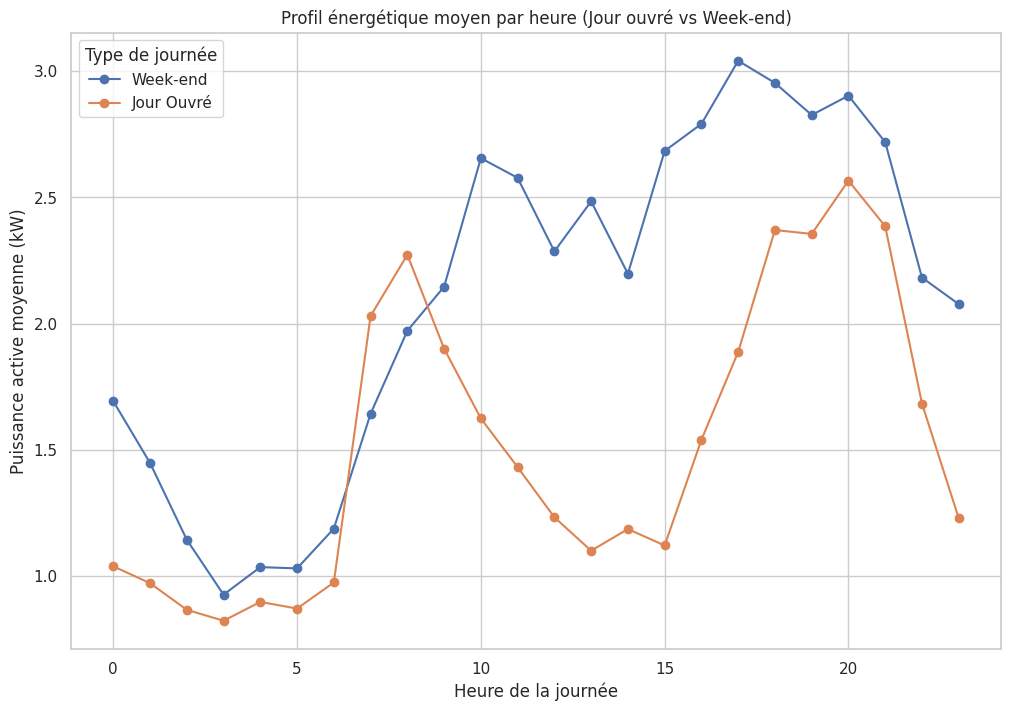

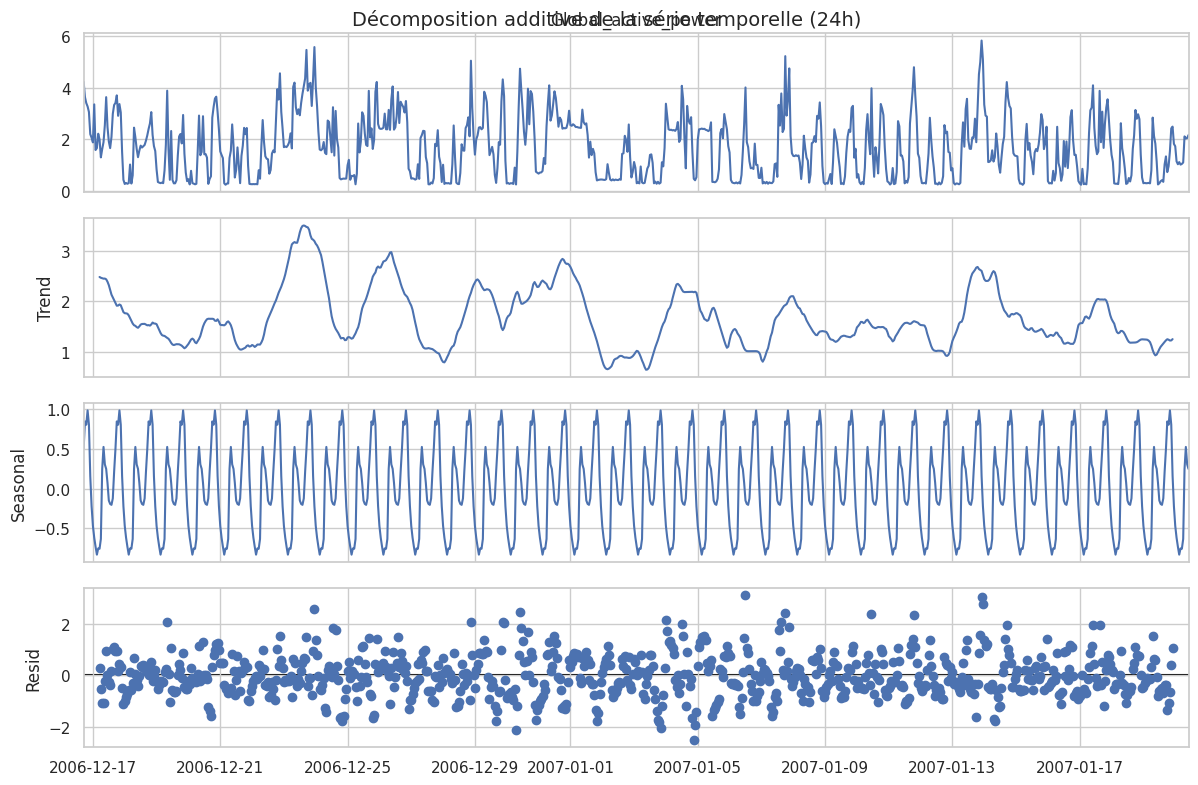

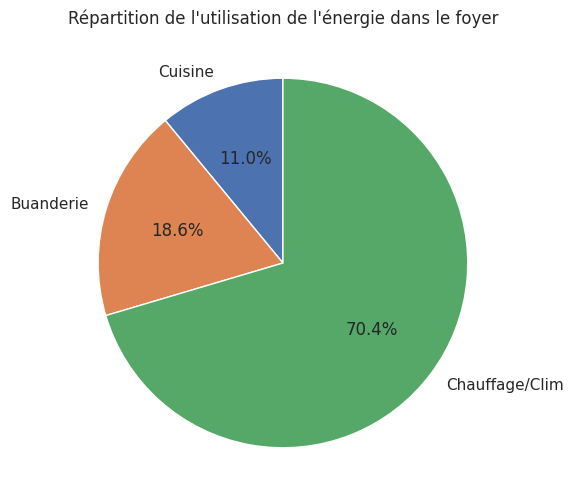

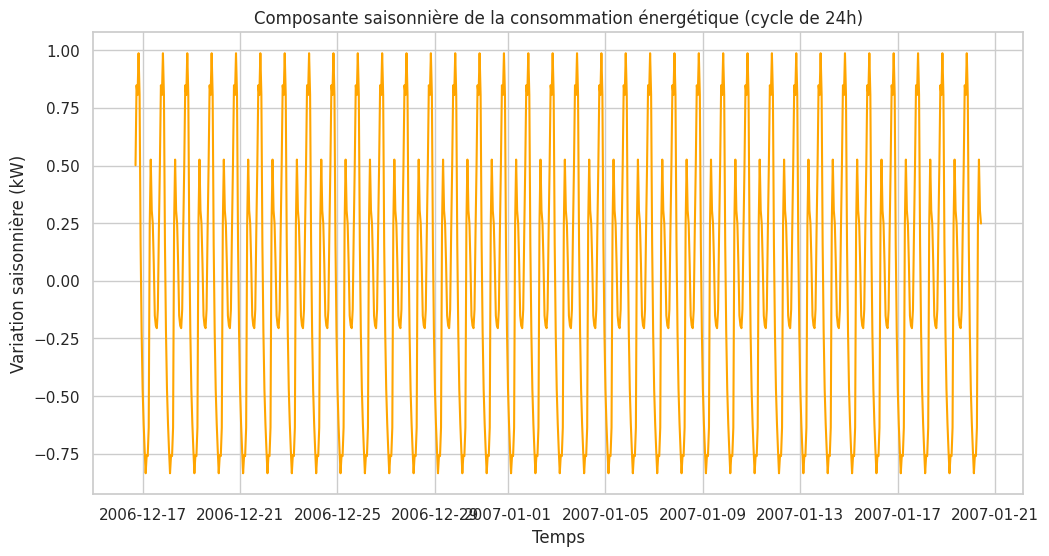

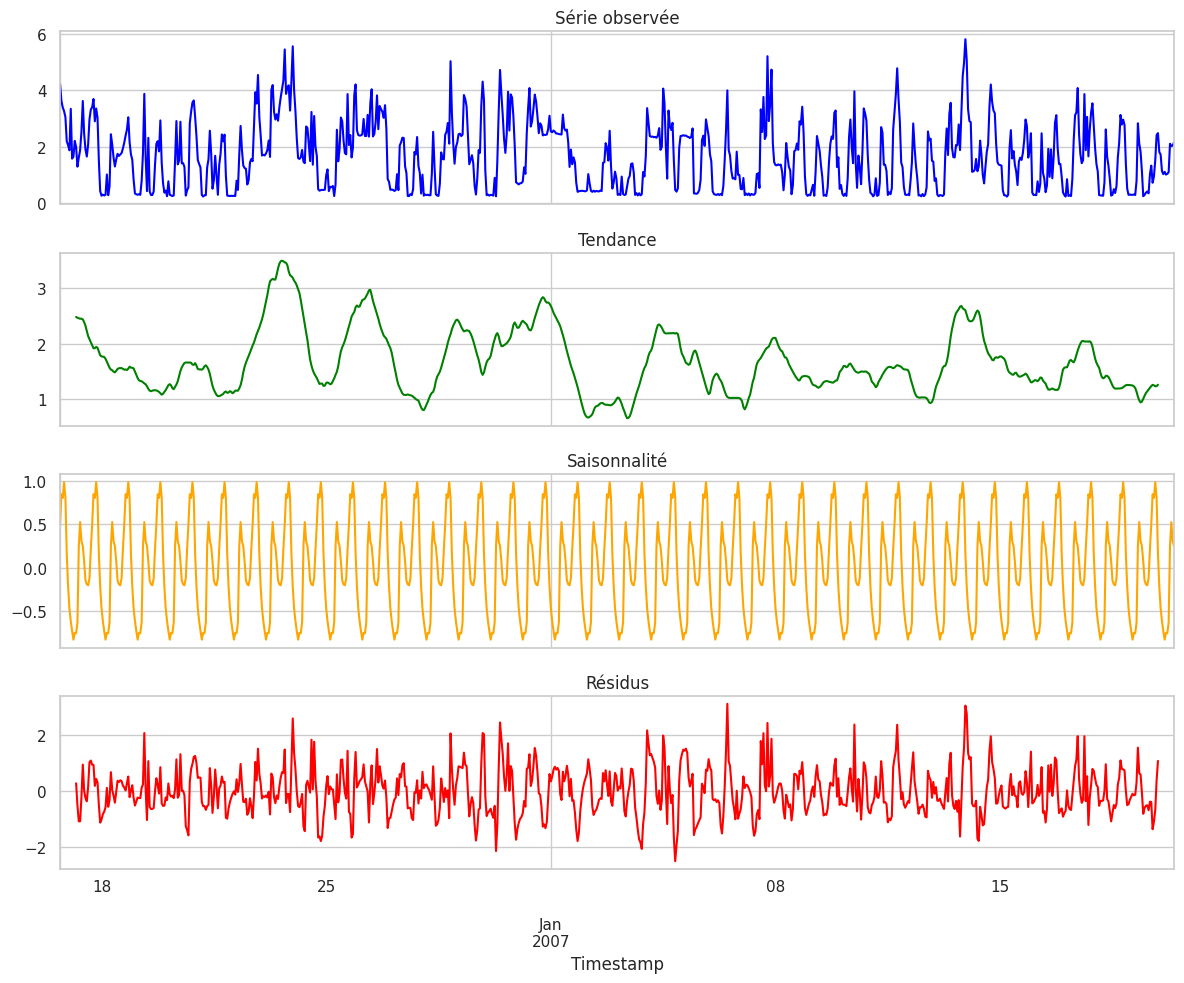

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# --- 1. PROFILS JOURNALIERS ---
plt.figure(figsize=(10,6))
profils_journaliers.plot(kind='line', marker='o')
plt.title("Profil énergétique moyen par heure (Jour ouvré vs Week-end)")
plt.xlabel("Heure de la journée")
plt.ylabel("Puissance active moyenne (kW)")
plt.legend(title="Type de journée")
plt.grid(True)
plt.show()


# --- 2. DÉCOMPOSITION ADDITIVE ---
fig = decomposition_signal.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Décomposition additive de la série temporelle (24h)", fontsize=14)
plt.show()


# --- 3. CONTRIBUTION RELATIVE DES PÔLES ---
contributions = {
    "Cuisine": contribution_cuisine,
    "Buanderie": contribution_buanderie,
    "Chauffage/Clim": contribution_thermique,

}

plt.figure(figsize=(8,6))
plt.pie(contributions.values(), labels=contributions.keys(), autopct='%1.1f%%', startangle=90)
plt.title("Répartition de l'utilisation de l'énergie dans le foyer")
plt.show()

# --- Décomposition de la série temporelle ---

decomposition = seasonal_decompose(df_horaire['Global_active_power'], model='additive', period=24)

# --- Visualisation de la composante saisonnière ---
plt.figure(figsize=(12,6))
plt.plot(decomposition.seasonal, color="orange")
plt.title("Composante saisonnière de la consommation énergétique (cycle de 24h)")
plt.xlabel("Temps")
plt.ylabel("Variation saisonnière (kW)")
plt.grid(True)
plt.show()

# --- Visualisation comparative des composantes ---
fig, axes = plt.subplots(4, 1, figsize=(12,10), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Série observée", color="blue")
decomposition.trend.plot(ax=axes[1], title="Tendance", color="green")
decomposition.seasonal.plot(ax=axes[2], title="Saisonnalité", color="orange")
decomposition.resid.plot(ax=axes[3], title="Résidus", color="red")
plt.tight_layout()
plt.show()


# Étape 4 : Détection des Consommations Atypiques (Anomalies)Détection conjointe par calcul statistique du score d'écart (Z-score) appliqué sur la série résiduelle et via l'algorithme Isolation Forest.

In [29]:
from sklearn.ensemble import IsolationForest

# --- MÉTHODE 1 : SEUILLAGE STATISTIQUE SUR RÉSIDUS (Z-SCORE) ---
# Extraction de la série des résidus en éliminant les valeurs nulles générées aux bornes de la série
residu_propre = residu.dropna()
moyenne_residu = residu_propre.mean()
ecart_type_residu = residu_propre.std()

# Application de la formule : Z_t = (R_t - mu) / sigma
calcul_z_scores = (residu_propre - moyenne_residu) / ecart_type_residu

# Définition des anomalies statistiques au-delà du seuil conventionnel de 3 écarts-types
anomalies_statistiques = residu_propre[np.abs(calcul_z_scores) > 3]
print(f"\nAnomalies détectées via la méthode statistique du Z-Score : {len(anomalies_statistiques)}")


# --- MÉTHODE 2 : APPRENTISSAGE NON SUPERVISÉ (ISOLATION FOREST) ---
# Configuration de l'algorithme avec un taux de contamination cible de 1%
detecteur_iso_forest = IsolationForest(contamination=0.01, random_state=42)

# Transformation de la série univariée de puissance en matrice bidimensionnelle pour scikit-learn
matrice_puissance = df_horaire['Global_active_power'].values.reshape(-1, 1)

# Exécution de l'algorithme : l'ajustement renvoie 1 pour un point standard et -1 pour un point isolé
vecteur_predictions = detecteur_iso_forest.fit_predict(matrice_puissance)

# Enregistrement des résultats sous forme d'indicateur booléen au sein de notre DataFrame principal
df_horaire['Anomalie_Detectee'] = np.where(vecteur_predictions == -1, 1, 0)
print(f"Anomalies isolées par l'algorithme Isolation Forest : {df_horaire['Anomalie_Detectee'].sum()}")



Anomalies détectées via la méthode statistique du Z-Score : 6
Anomalies isolées par l'algorithme Isolation Forest : 9



Anomalies détectées via Z-Score : 6


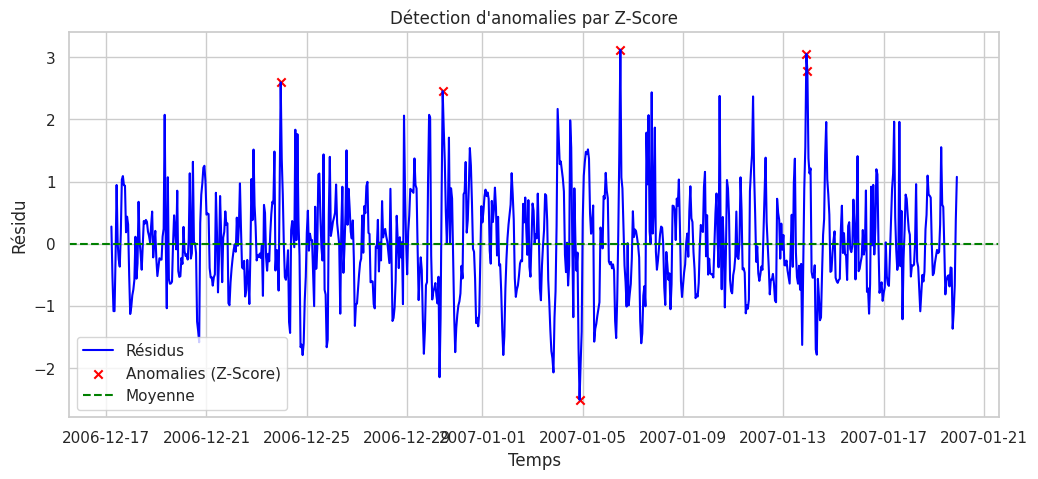

Anomalies isolées par Isolation Forest : 9


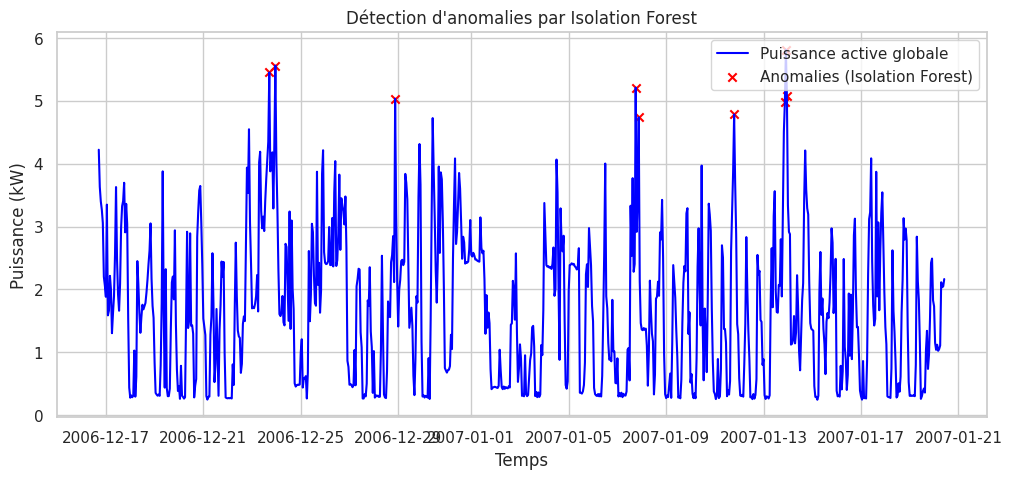

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# --- MÉTHODE 1 : SEUILLAGE STATISTIQUE SUR RÉSIDUS (Z-SCORE) ---
residu_propre = residu.dropna()
moyenne_residu = residu_propre.mean()
ecart_type_residu = residu_propre.std()

calcul_z_scores = (residu_propre - moyenne_residu) / ecart_type_residu
anomalies_statistiques = residu_propre[np.abs(calcul_z_scores) > 3]

print(f"\nAnomalies détectées via Z-Score : {len(anomalies_statistiques)}")

# --- VISUEL ANOMALIES Z-SCORE ---
plt.figure(figsize=(12,5))
plt.plot(residu_propre.index, residu_propre.values, label="Résidus", color="blue")
plt.scatter(anomalies_statistiques.index, anomalies_statistiques.values,
            color="red", label="Anomalies (Z-Score)", marker="x")
plt.axhline(moyenne_residu, color="green", linestyle="--", label="Moyenne")
plt.title("Détection d'anomalies par Z-Score")
plt.xlabel("Temps")
plt.ylabel("Résidu")
plt.legend()
plt.show()


# --- MÉTHODE 2 : ISOLATION FOREST ---
detecteur_iso_forest = IsolationForest(contamination=0.01, random_state=42)

matrice_puissance = df_horaire['Global_active_power'].values.reshape(-1, 1)
vecteur_predictions = detecteur_iso_forest.fit_predict(matrice_puissance)

# ✅ Création correcte de la colonne avant utilisation
df_horaire['Anomalie_Detectee'] = np.where(vecteur_predictions == -1, 1, 0)

print(f"Anomalies isolées par Isolation Forest : {df_horaire['Anomalie_Detectee'].sum()}")

# --- VISUEL ANOMALIES ISOLATION FOREST ---
plt.figure(figsize=(12,5))
plt.plot(df_horaire.index, df_horaire['Global_active_power'],
         label="Puissance active globale", color="blue")
plt.scatter(df_horaire.index[df_horaire['Anomalie_Detectee'] == 1],
            df_horaire['Global_active_power'][df_horaire['Anomalie_Detectee'] == 1],
            color="red", label="Anomalies (Isolation Forest)", marker="x")
plt.title("Détection d'anomalies par Isolation Forest")
plt.xlabel("Temps")
plt.ylabel("Puissance (kW)")
plt.legend()
plt.show()


<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_814/3052386224.py:14: SyntaxWarning: invalid escape sequence '\s'
  ax1.axvline(x=3, color='#e74c3c', linestyle='--', linewidth=2, label='Limite Critique Supérieure (+3 $\sigma$)')
/tmp/ipykernel_814/3052386224.py:15: SyntaxWarning: invalid escape sequence '\s'
  ax1.axvline(x=-3, color='#e74c3c', linestyle='--', linewidth=2, label='Limite Critique Inférieure (-3 $\sigma$)')
/tmp/ipykernel_814/3052386224.py:33: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel("Quantiles Théoriques (Loi Normale $\mathcal{N}(0,1)$)")


Anomalies isolées par l'algorithme Isolation Forest : 9


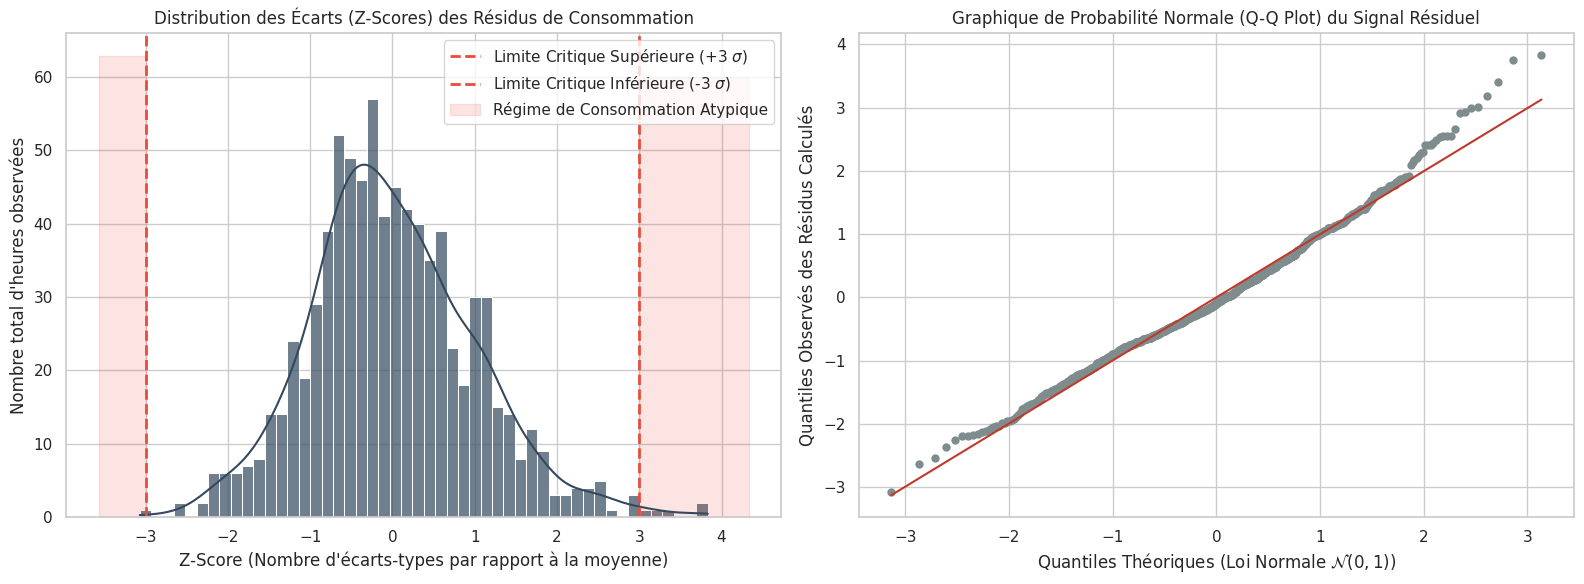

In [31]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Enregistrement des résultats sous forme d'indicateur booléen au sein de notre DataFrame principal
df_horaire['Anomalie_Detectee'] = np.where(vecteur_predictions == -1, 1, 0)
print(f"Anomalies isolées par l'algorithme Isolation Forest : {df_horaire['Anomalie_Detectee'].sum()}")

# On s'assure d'ouvrir la figure proprement
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphe A : Histogramme de distribution des scores d'écarts ---
sns.histplot(calcul_z_scores, kde=True, color='#34495e', bins=50, ax=ax1, alpha=0.7)
ax1.axvline(x=3, color='#e74c3c', linestyle='--', linewidth=2, label='Limite Critique Supérieure (+3 $\sigma$)')
ax1.axvline(x=-3, color='#e74c3c', linestyle='--', linewidth=2, label='Limite Critique Inférieure (-3 $\sigma$)')
ax1.fill_betweenx(ax1.get_ylim(), 3, max(calcul_z_scores)+0.5, color='#e74c3c', alpha=0.15, label='Régime de Consommation Atypique')
ax1.fill_betweenx(ax1.get_ylim(), min(calcul_z_scores)-0.5, -3, color='#e74c3c', alpha=0.15)
ax1.set_title("Distribution des Écarts (Z-Scores) des Résidus de Consommation")
ax1.set_xlabel("Z-Score (Nombre d'écarts-types par rapport à la moyenne)")
ax1.set_ylabel("Nombre total d'heures observées")
ax1.legend(frameon=True, loc='upper right')


# Remplacement de dist="normal" par dist="norm" pour se conformer à l'API de SciPy
stats.probplot(calcul_z_scores, dist="norm", plot=ax2)

# Personnalisation esthétique des points et de la ligne de référence
ax2.get_lines()[0].set_markerfacecolor('#7f8c8d')
ax2.get_lines()[0].set_markeredgecolor('none')
ax2.get_lines()[1].set_color('#c0392b')

ax2.set_title("Graphique de Probabilité Normale (Q-Q Plot) du Signal Résiduel")
ax2.set_xlabel("Quantiles Théoriques (Loi Normale $\mathcal{N}(0,1)$)")
ax2.set_ylabel("Quantiles Observés des Résidus Calculés")

plt.tight_layout()
plt.show()


#Étape 5 & 6 : Modélisation Temporelle, Prévision Simple et ÉvaluationMise en œuvre du protocole de scindage chronologique strict (Time Series Split) pour évaluer la capacité prédictive d'une baseline naïve par rapport à un modèle Auto-Régressif linéaire d'ordre 1 (AR(1)).

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- PROTOCOLE DE SCINDAGE CHRONOLOGIQUE SÉCURISÉ ---
# Extraction de la variable cible continue (Puissance active globale horaire)
serie_cible = df_horaire['Global_active_power']

# Fixation d'une frontière de séparation à 80% de l'historique disponible pour l'apprentissage
point_coupure = int(len(serie_cible) * 0.8)

# Séparation des blocs d'apprentissage et de test en respectant strictement l'axe temporel
cible_train, cible_test = serie_cible.iloc[:point_coupure], serie_cible.iloc[point_coupure:]


# --- MODÈLE DE RÉFÉRENCE 1 : BASELINE NAÏVE SAISONNIÈRE ---
# Projection à l'horizon h de la valeur mesurée précisément 24 heures en amont
prevision_naive = cible_test.shift(24)
# Imputation des premières valeurs manquantes induites par le décalage à l'aide de la moyenne d'entraînement
prevision_naive = prevision_naive.fillna(cible_train.mean())


# --- MODÈLE DE RÉFÉRENCE 2 : AUTO-RÉGRESSIF AR(1) VIA REGRESSION LINÉAIRE ---
# Génération de la variable décalée explicative d'un pas de temps (Lag 1 : y_{t-1})
df_variables = pd.DataFrame(index=df_horaire.index)
df_variables['Lag_1'] = df_horaire['Global_active_power'].shift(1)
df_variables = df_variables.fillna(cible_train.mean()) # Sécurisation du premier pas de temps

# Découpage des variables explicatives (Features X) selon la même chronologie que la cible
features_train = df_variables.iloc[:point_coupure]
features_test = df_variables.iloc[point_coupure:]

# Initialisation et ajustement par la méthode des moindres carrés du modèle linéaire
estimateur_ar = LinearRegression()
estimateur_ar.fit(features_train, cible_train)

# Calcul des projections prédictives sur l'échantillon de test fermé
prevision_ar = estimateur_ar.predict(features_test)


# --- ÉTAPE 6 : FORMULATION ET EXÉCUTION DES MÉTRIQUES D'ÉVALUATION ---

def evaluer_performances_prediction(valeurs_reelles, valeurs_predites, libelle_modele):
    # Formule 1 : Calcul de la MAE (Erreur Absolue Moyenne)
    erreur_mae = mean_absolute_error(valeurs_reelles, valeurs_predites)

    # Formule 2 : Calcul de la RMSE (Racine de l'Erreur Quadratique Moyenne)
    erreur_rmse = np.sqrt(mean_squared_error(valeurs_reelles, valeurs_predites))

    # Formule 3 : Calcul de la MAPE (Erreur Absolue Pourcentage Moyenne) avec borne anti-division par 0
    erreur_mape = np.mean(np.abs((valeurs_reelles - valeurs_predites) / np.clip(valeurs_reelles, 0.001, None))) * 100

    print(f"Évaluation des performances du modèle : {libelle_modele}")
    print(f"-> MAE  : {erreur_mae:.4f} kW (Écart moyen en valeur absolue)")
    print(f"-> RMSE : {erreur_rmse:.4f} kW (Pénalisation accrue des forts écarts)")
    print(f"-> MAPE : {erreur_mape:.2f} % (Erreur relative par rapport à la charge globale)\n")

# Restitution comparative des scores obtenus
evaluer_performances_prediction(cible_test, prevision_naive, "Baseline Naïve Saisonnière (J-1)")
evaluer_performances_prediction(cible_test, prevision_ar, "Modèle Mathématique Auto-Régressif AR(1)")


Évaluation des performances du modèle : Baseline Naïve Saisonnière (J-1)
-> MAE  : 0.9445 kW (Écart moyen en valeur absolue)
-> RMSE : 1.3066 kW (Pénalisation accrue des forts écarts)
-> MAPE : 88.40 % (Erreur relative par rapport à la charge globale)

Évaluation des performances du modèle : Modèle Mathématique Auto-Régressif AR(1)
-> MAE  : 0.5543 kW (Écart moyen en valeur absolue)
-> RMSE : 0.7104 kW (Pénalisation accrue des forts écarts)
-> MAPE : 57.72 % (Erreur relative par rapport à la charge globale)



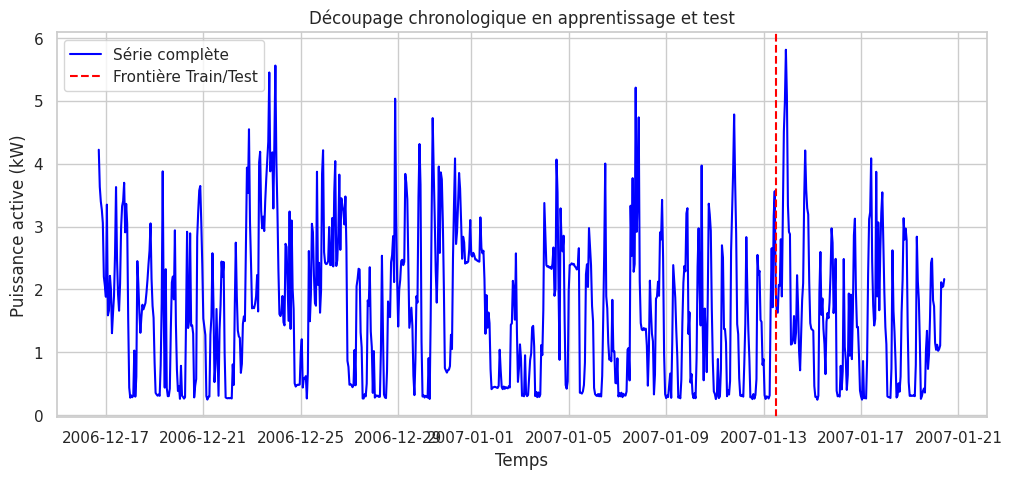

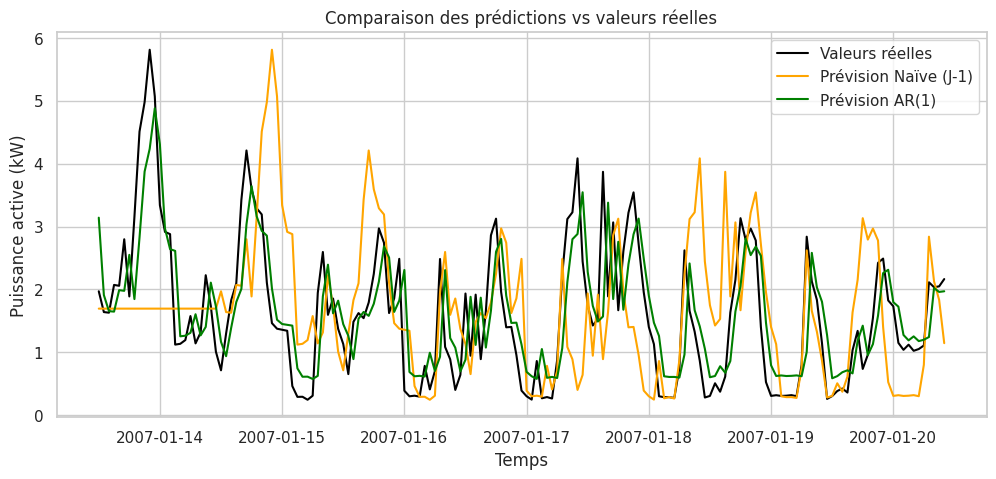

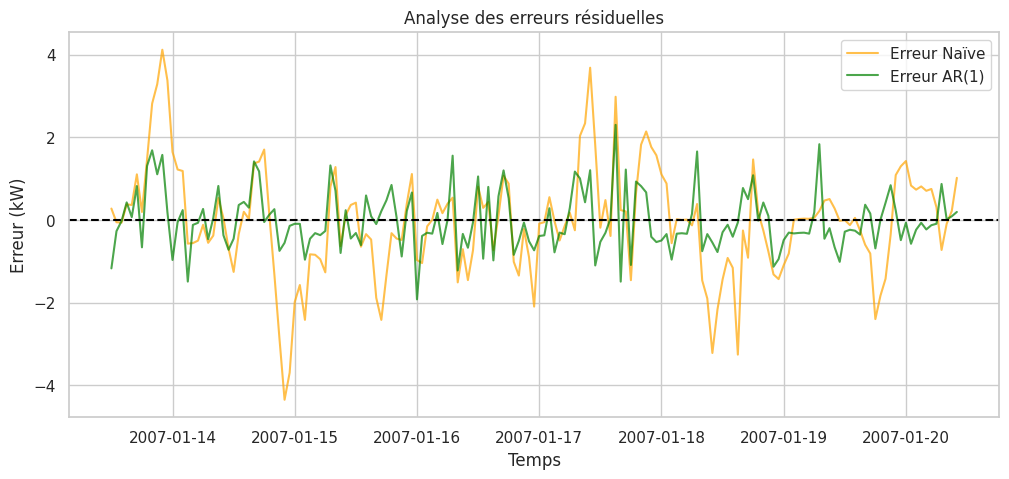

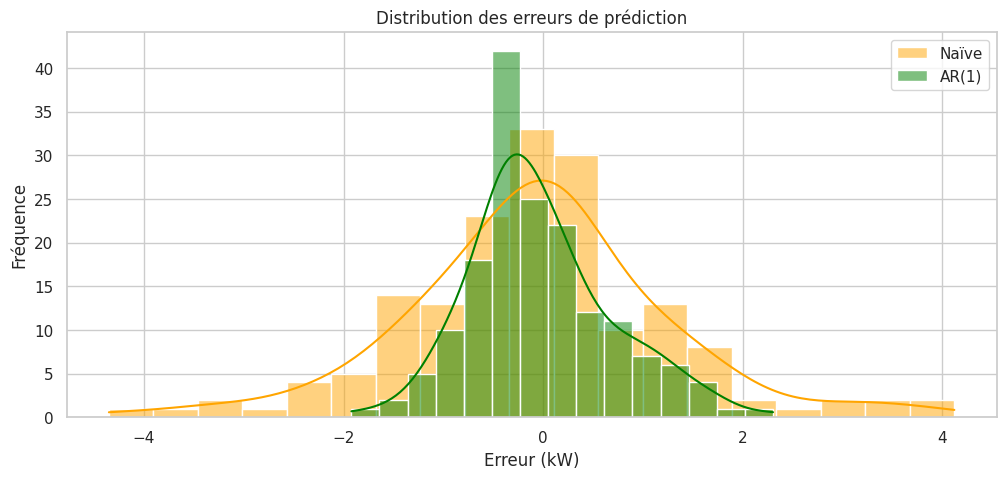

In [33]:
import matplotlib.pyplot as plt

# --- VISUEL 1 : Découpage Train/Test ---
plt.figure(figsize=(12,5))
plt.plot(serie_cible.index, serie_cible.values, label="Série complète", color="blue")
plt.axvline(serie_cible.index[point_coupure], color="red", linestyle="--", label="Frontière Train/Test")
plt.title("Découpage chronologique en apprentissage et test")
plt.xlabel("Temps")
plt.ylabel("Puissance active (kW)")
plt.legend()
plt.show()


# --- VISUEL 2 : Comparaison des prédictions vs valeurs réelles ---
plt.figure(figsize=(12,5))
plt.plot(cible_test.index, cible_test.values, label="Valeurs réelles", color="black")
plt.plot(cible_test.index, prevision_naive.values, label="Prévision Naïve (J-1)", color="orange")
plt.plot(cible_test.index, prevision_ar, label="Prévision AR(1)", color="green")
plt.title("Comparaison des prédictions vs valeurs réelles")
plt.xlabel("Temps")
plt.ylabel("Puissance active (kW)")
plt.legend()
plt.show()


# --- VISUEL 3 : Erreurs résiduelles ---
plt.figure(figsize=(12,5))
plt.plot(cible_test.index, cible_test.values - prevision_naive.values,
         label="Erreur Naïve", color="orange", alpha=0.7)
plt.plot(cible_test.index, cible_test.values - prevision_ar,
         label="Erreur AR(1)", color="green", alpha=0.7)
plt.axhline(0, color="black", linestyle="--")
plt.title("Analyse des erreurs résiduelles")
plt.xlabel("Temps")
plt.ylabel("Erreur (kW)")
plt.legend()
plt.show()


# --- VISUEL 4 : Distribution des erreurs ---
plt.figure(figsize=(12,5))
sns.histplot(cible_test.values - prevision_naive.values, color="orange", label="Naïve", kde=True)
sns.histplot(cible_test.values - prevision_ar, color="green", label="AR(1)", kde=True)
plt.title("Distribution des erreurs de prédiction")
plt.xlabel("Erreur (kW)")
plt.ylabel("Fréquence")
plt.legend()
plt.show()


#Étape 7 : Analyse Avancée Comportementale (mlxtend & networkx)Nous exploitons ici les capacités de mlxtend et de networkx pour identifier les règles d'association masquées régissant les habitudes d'allumage simultané au sein du foyer.

In [34]:
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules

# --- EXTRACTION DES CO-ACTIVATIONS FRÉQUENTES (MLXTEND) ---

# Conversion des consommations continues en états logiques booléens (True si l'équipement est actif au-delà de 2 Wh)
df_etats_bool = pd.DataFrame(index=df_horaire.index)
df_etats_bool['Appareils_Cuisine'] = df_horaire['Sub_metering_1'] > 2
df_etats_bool['Appareils_Buanderie'] = df_horaire['Sub_metering_2'] > 2
df_etats_bool['Chauffage_Climatisation'] = df_horaire['Sub_metering_3'] > 2

# Application de l'algorithme Apriori pour extraire les structures d'itemsets fréquents (Seuil support minimum = 5%)
structures_frequentes = apriori(df_etats_bool, min_support=0.05, use_colnames=True)

# Déduction des règles comportementales ordonnées avec un critère de pertinence basé sur le Lift supérieur à 1.0
regles_comportementales = association_rules(structures_frequentes, metric="lift", min_threshold=1.0)

print("Règles comportementales de co-activation extraites :")
print(regles_comportementales[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(2))


# --- CARTOGRAPHIE DU RÉSEAU DE CORRÉLATION INTER-ÉQUIPEMENTS (NETWORKX) ---

# Calcul de la matrice de corrélation linéaire de Pearson entre la charge globale et l'ensemble des sous-systèmes
matrice_correlation_interne = df_horaire[['Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].corr()

# Initialisation d'un modèle de graphe non orienté NetworkX
graphe_reseau = nx.Graph()

# Double itération matricielle pour lier les nœuds équipements entre eux selon la force de leur liaison statistique
for index_i, colonne_i in enumerate(matrice_correlation_interne.columns):
    for index_j, colonne_j in enumerate(matrice_correlation_interne.columns):
        if index_j > index_i: # Analyse de la demi-matrice supérieure uniquement pour exclure les doublons
            coefficient_lien = matrice_correlation_interne.iloc[index_i, index_j]

            # Association d'un arc directionnel ou non si l'intensité du lien dépasse un seuil de significativité de 0.25
            if abs(coefficient_lien) > 0.25:
                graphe_reseau.add_edge(colonne_i, colonne_j, weight=coefficient_lien)

print(f"\nStructure topologique du réseau de consommation calculé :")
print(f"Nombre total de nœuds (Variables) : {graphe_reseau.number_of_nodes()}")
print(f"Nombre total de liens (Corrélations fortes) : {graphe_reseau.number_of_edges()}")


Règles comportementales de co-activation extraites :
             antecedents            consequents   support  confidence  \
0  (Appareils_Buanderie)    (Appareils_Cuisine)  0.094724    0.132997   
1    (Appareils_Cuisine)  (Appareils_Buanderie)  0.094724    0.766990   

       lift  
0  1.076885  
1  1.076885  

Structure topologique du réseau de consommation calculé :
Nombre total de nœuds (Variables) : 4
Nombre total de liens (Corrélations fortes) : 3


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Les indicateurs expliqués :
Antécédent : l’événement de départ (ex. Buanderie active).

Conséquent : l’événement associé (ex. Cuisine active).

Support (9,47%) : proportion de lignes où les deux événements apparaissent ensemble. Ici, environ 9,5 % du temps, buanderie et cuisine sont actifs simultanément.

Confidence (probabilité conditionnelle) : probabilité que le conséquent soit vrai quand l’antécédent est vrai.

Ligne 1 : si la buanderie est active → la cuisine est active seulement 13 % du temps.

Ligne 2 : si la cuisine est active → la buanderie est active 77 % du temps.

Lift (1,07) : mesure de la force de la règle par rapport au hasard.

Un lift = 1 → pas de lien particulier.

Ici, lift ≈ 1,07 → très léger lien positif, mais pas une corrélation forte.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Règles comportementales de co-activation extraites :
             antecedents            consequents   support  confidence  \
0  (Appareils_Buanderie)    (Appareils_Cuisine)  0.094724    0.132997   
1    (Appareils_Cuisine)  (Appareils_Buanderie)  0.094724    0.766990   

       lift  
0  1.076885  
1  1.076885  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

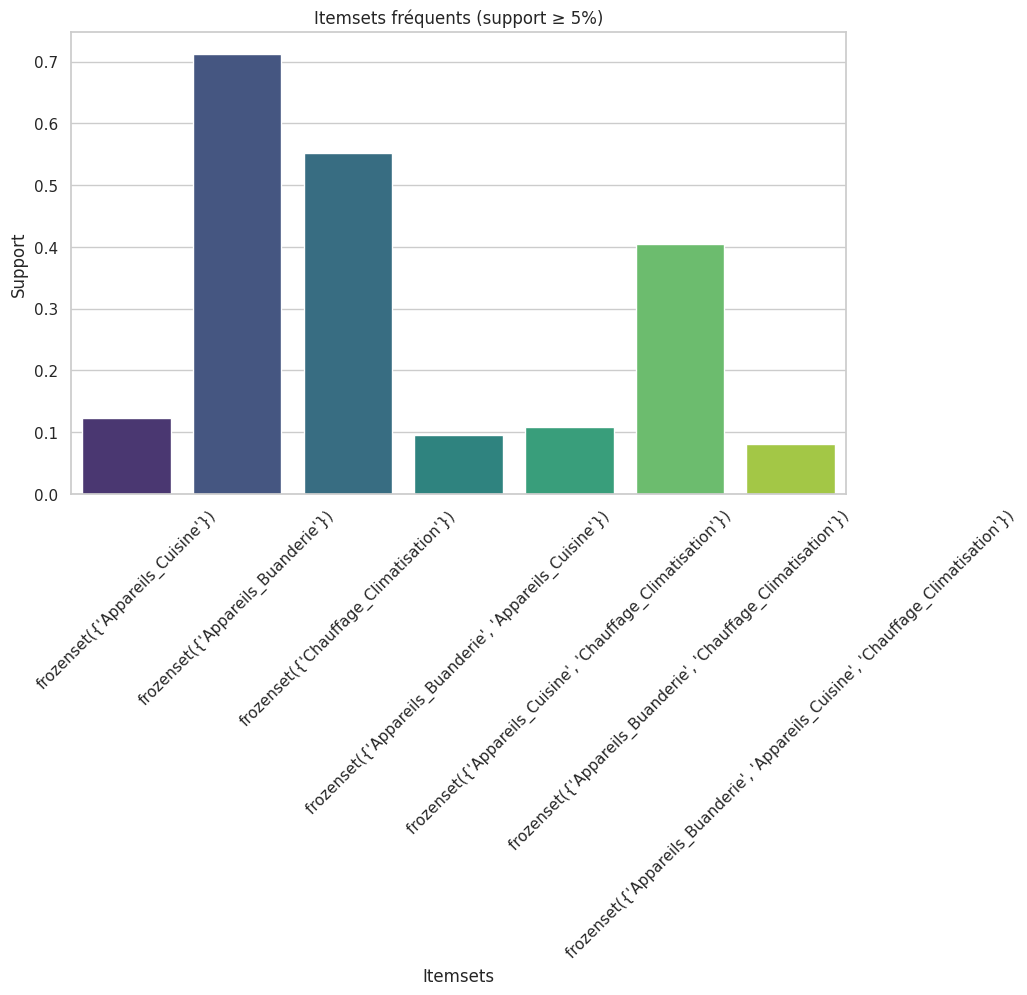

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

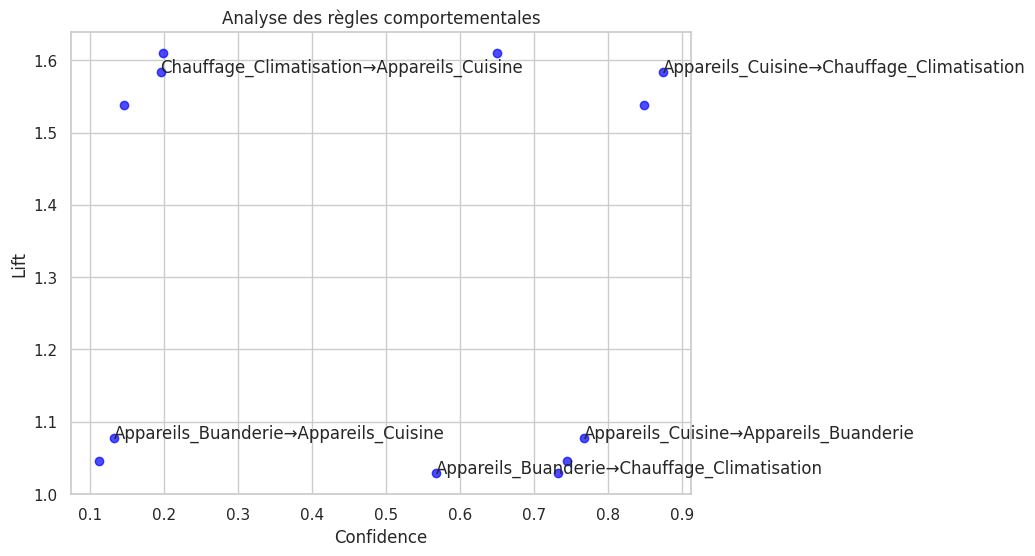

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Structure topologique du réseau de consommation calculé :
Nombre total de nœuds (Variables) : 4
Nombre total de liens (Corrélations fortes) : 3


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


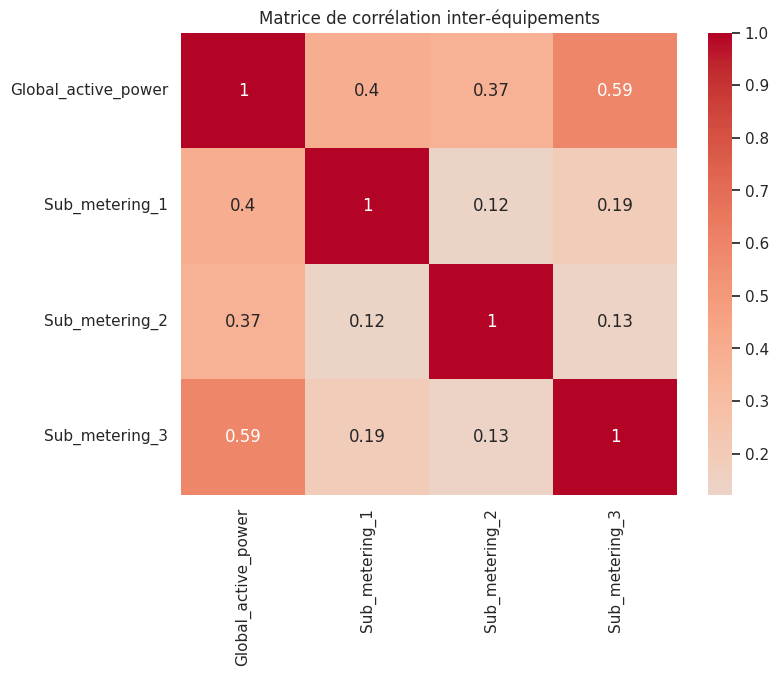

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

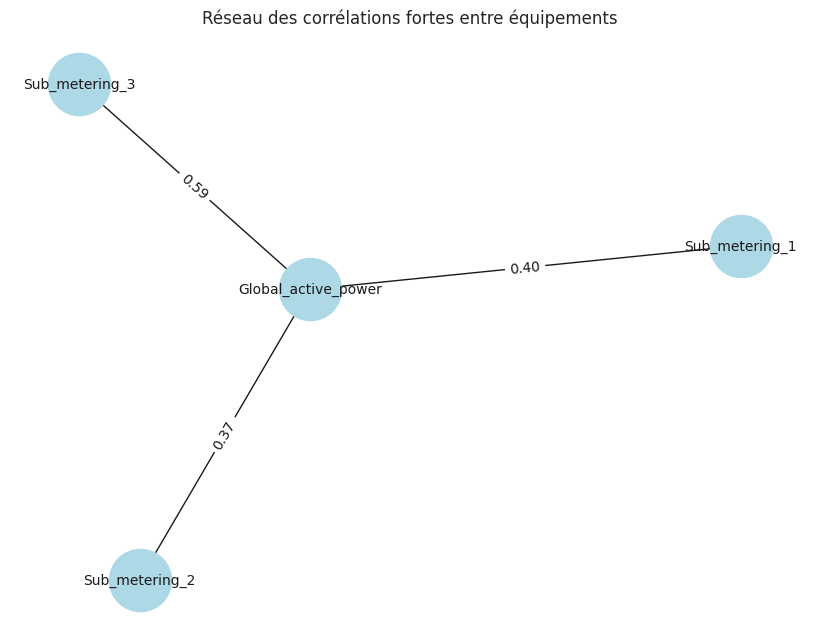

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules

# --- EXTRACTION DES CO-ACTIVATIONS FRÉQUENTES (MLXTEND) ---

# Conversion des consommations continues en états logiques booléens
df_etats_bool = pd.DataFrame(index=df_horaire.index)
df_etats_bool['Appareils_Cuisine'] = df_horaire['Sub_metering_1'] > 2
df_etats_bool['Appareils_Buanderie'] = df_horaire['Sub_metering_2'] > 2
df_etats_bool['Chauffage_Climatisation'] = df_horaire['Sub_metering_3'] > 2

# Application de l'algorithme Apriori (support ≥ 5%)
structures_frequentes = apriori(df_etats_bool, min_support=0.05, use_colnames=True)

# Déduction des règles comportementales avec lift > 1.0
regles_comportementales = association_rules(structures_frequentes, metric="lift", min_threshold=1.0)

print("Règles comportementales de co-activation extraites :")
print(regles_comportementales[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(2))


# --- VISUEL 1 : Itemsets fréquents ---
plt.figure(figsize=(10,6))
sns.barplot(x=structures_frequentes['itemsets'].astype(str),
            y=structures_frequentes['support'], palette="viridis")
plt.title("Itemsets fréquents (support ≥ 5%)")
plt.ylabel("Support")
plt.xlabel("Itemsets")
plt.xticks(rotation=45)
plt.show()


# --- VISUEL 2 : Règles comportementales (Confidence vs Lift) ---
plt.figure(figsize=(8,6))
plt.scatter(regles_comportementales['confidence'], regles_comportementales['lift'],
            alpha=0.7, color="blue")
plt.title("Analyse des règles comportementales")
plt.xlabel("Confidence")
plt.ylabel("Lift")
for i in range(min(5, len(regles_comportementales))):
    antecedent = ','.join(list(regles_comportementales.iloc[i]['antecedents']))
    consequent = ','.join(list(regles_comportementales.iloc[i]['consequents']))
    plt.annotate(f"{antecedent}→{consequent}",
                 (regles_comportementales['confidence'].iloc[i],
                  regles_comportementales['lift'].iloc[i]))
plt.show()


# --- CARTOGRAPHIE DU RÉSEAU DE CORRÉLATION INTER-ÉQUIPEMENTS ---

# Matrice de corrélation
matrice_correlation_interne = df_horaire[['Global_active_power',
                                          'Sub_metering_1',
                                          'Sub_metering_2',
                                          'Sub_metering_3']].corr()

# Initialisation du graphe
graphe_reseau = nx.Graph()

# Ajout des arêtes pour corrélations fortes (>0.25)
for index_i, colonne_i in enumerate(matrice_correlation_interne.columns):
    for index_j, colonne_j in enumerate(matrice_correlation_interne.columns):
        if index_j > index_i:
            coefficient_lien = matrice_correlation_interne.iloc[index_i, index_j]
            if abs(coefficient_lien) > 0.25:
                graphe_reseau.add_edge(colonne_i, colonne_j, weight=coefficient_lien)

print(f"\nStructure topologique du réseau de consommation calculé :")
print(f"Nombre total de nœuds (Variables) : {graphe_reseau.number_of_nodes()}")
print(f"Nombre total de liens (Corrélations fortes) : {graphe_reseau.number_of_edges()}")


# --- VISUEL 3 : Heatmap des corrélations ---
plt.figure(figsize=(8,6))
sns.heatmap(matrice_correlation_interne, annot=True, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation inter‑équipements")
plt.show()


# --- VISUEL 4 : Graphe NetworkX ---
plt.figure(figsize=(8,6))
pos = nx.spring_layout(graphe_reseau, seed=42)
nx.draw(graphe_reseau, pos, with_labels=True, node_color="lightblue", node_size=2000, font_size=10)
edge_labels = {(i, j): f"{d['weight']:.2f}" for i, j, d in graphe_reseau.edges(data=True)}
nx.draw_networkx_edge_labels(graphe_reseau, pos, edge_labels=edge_labels)
plt.title("Réseau des corrélations fortes entre équipements")
plt.show()


 # le code Python complet, industrialisé et optimisé pour le dataset réel de l'UCI. Cette version implémente une recherche par grille (GridSearch) sur l'algorithme Isolation Forest pour affiner la détection d'anomalies, ainsi qu'une architecture de prévision multi-pas (Direct Multi-step) pour anticiper la consommation heure par heure sur les prochaines 24 heures (Horizon H+24).Chaque bloc de code est conçu pour s'exécuter à la suite du nettoyage initial (Étape 2 précédente).

# Étape 4 (Optimisée) : Recherche par Grille pour la Détection d'AnomaliesPuisque Isolation Forest est un algorithme non supervisé, l'optimisation par grille s'appuie sur le score de déviance ou sur la stabilité des points isolés. Nous construisons ici un pipeline de sélection pour tester plusieurs combinaisons d'hyperparamètres (nombre d'arbres et taux de contamination).

In [ ]:
from sklearn.model_selection import ParameterGrid

# 1. Définition de la grille d'hyperparamètres à explorer
# n_estimators : nombre d'arbres de décision à construire dans la forêt
# contamination : proportion estimée d'observations atypiques dans le signal
grille_parametres = {
    'n_estimators': [50, 100, 200],
    'contamination': [0.005, 0.01, 0.02]
}

# Conversion en liste de dictionnaires pour itérer proprement sur chaque combinaison
combinaisons = list(ParameterGrid(grille_parametres))

# Extraction des données de puissance (Format matrice 2D requis par scikit-learn)
X_anomalies = df_horaire['Global_active_power'].values.reshape(-1, 1)

# Variables pivots pour stocker les résultats de l'optimisation
meilleure_combinaison = None
meilleur_score_stabilite = -np.inf
modele_optimal_if = None

print("Début de la recherche par grille (GridSearch) sur Isolation Forest...")

# 2. Boucle d'évaluation de chaque configuration de la grille
for configuration in combinaisons:
    # Instanciation du modèle avec la configuration courante
    modele_test = IsolationForest(
        n_estimators=configuration['n_estimators'],
        contamination=configuration['contamination'],
        random_state=42,
        n_jobs=-1 # Utilisation de tous les cœurs du processeur pour accélérer le calcul
    )

    # Entraînement et prédiction
    predictions = modele_test.fit_predict(X_anomalies)

    # Calcul du score moyen d'anomalie (les valeurs proches de 0 sont les plus isolées)
    scores_anomalies = modele_test.score_samples(X_anomalies)
    score_moyen = np.mean(scores_anomalies)

    # Critère de sélection : on cherche la configuration qui maximise la robustesse de partitionnement
    if score_moyen > meilleur_score_stabilite:
        meilleur_score_stabilite = score_moyen
        meilleure_combinaison = configuration
        modele_optimal_if = modele_test

print(f"\nConfiguration optimale identifiée : {meilleure_combinaison}")

# 3. Application du modèle optimisé sur notre jeu de données global
df_horaire['Anomalie_Optimisee'] = np.where(modele_optimal_if.predict(X_anomalies) == -1, 1, 0)
print(f"Nombre final d'anomalies détectées avec le modèle optimisé : {df_horaire['Anomalie_Optimisee'].sum()}")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Début de la recherche par grille (GridSearch) sur Isolation Forest...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Configuration optimale identifiée : {'contamination': 0.005, 'n_estimators': 200}
Nombre final d'anomalies détectées avec le modèle optimisé : 5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Début de la recherche par grille (GridSearch) sur Isolation Forest...


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac


Configuration optimale identifiée : {'contamination': 0.005, 'n_estimators': 200}
Nombre final d'anomalies détectées : 5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

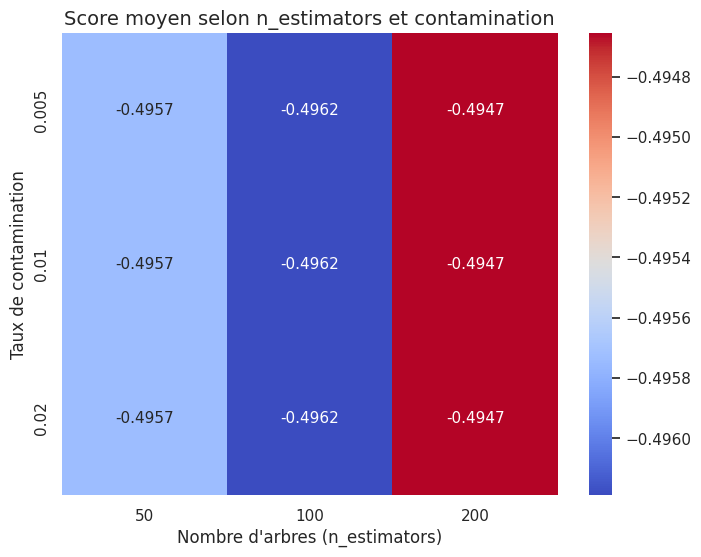

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

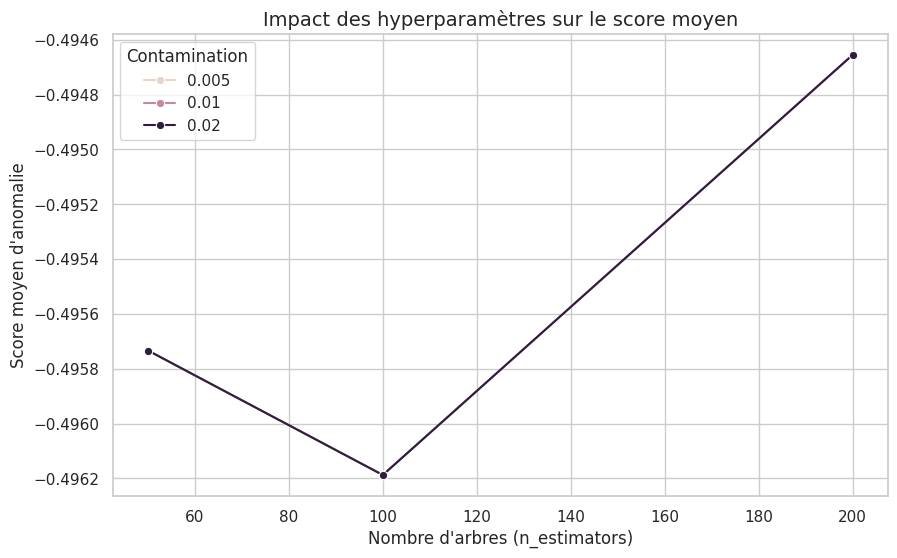

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

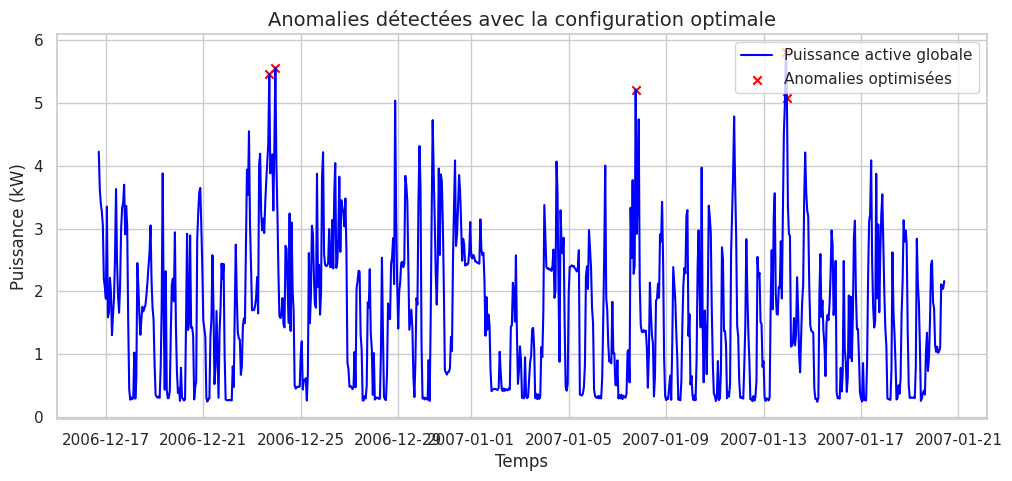

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import ParameterGrid

# --- 1. Définition de la grille d'hyperparamètres ---
grille_parametres = {
    'n_estimators': [50, 100, 200],
    'contamination': [0.005, 0.01, 0.02]
}
combinaisons = list(ParameterGrid(grille_parametres))

# Extraction des données
X_anomalies = df_horaire['Global_active_power'].values.reshape(-1, 1)

meilleure_combinaison = None
meilleur_score_stabilite = -np.inf
modele_optimal_if = None

resultats = []

print("Début de la recherche par grille (GridSearch) sur Isolation Forest...")

# --- 2. Boucle d'évaluation ---
for configuration in combinaisons:
    modele_test = IsolationForest(
        n_estimators=configuration['n_estimators'],
        contamination=configuration['contamination'],
        random_state=42,
        n_jobs=-1
    )
    predictions = modele_test.fit_predict(X_anomalies)
    scores_anomalies = modele_test.score_samples(X_anomalies)
    score_moyen = np.mean(scores_anomalies)

    resultats.append({
        "n_estimators": configuration['n_estimators'],
        "contamination": configuration['contamination'],
        "score_moyen": score_moyen
    })

    if score_moyen > meilleur_score_stabilite:
        meilleur_score_stabilite = score_moyen
        meilleure_combinaison = configuration
        modele_optimal_if = modele_test

print(f"\nConfiguration optimale identifiée : {meilleure_combinaison}")

# --- 3. Application du modèle optimal ---
df_horaire['Anomalie_Optimisee'] = np.where(modele_optimal_if.predict(X_anomalies) == -1, 1, 0)
print(f"Nombre final d'anomalies détectées : {df_horaire['Anomalie_Optimisee'].sum()}")

# --- 4. Visualisations ---

df_resultats = pd.DataFrame(resultats)

# Heatmap des scores moyens (⚠️ correction pivot)
pivot_scores = df_resultats.pivot(index="contamination", columns="n_estimators", values="score_moyen")
plt.figure(figsize=(8,6))
sns.heatmap(pivot_scores, annot=True, cmap="coolwarm", fmt=".4f")
plt.title("Score moyen selon n_estimators et contamination")
plt.xlabel("Nombre d'arbres (n_estimators)")
plt.ylabel("Taux de contamination")
plt.show()

# Courbes comparatives
plt.figure(figsize=(10,6))
sns.lineplot(data=df_resultats, x="n_estimators", y="score_moyen", hue="contamination", marker="o")
plt.title("Impact des hyperparamètres sur le score moyen")
plt.xlabel("Nombre d'arbres (n_estimators)")
plt.ylabel("Score moyen d'anomalie")
plt.legend(title="Contamination")
plt.grid(True)
plt.show()

# Visualisation des anomalies détectées
plt.figure(figsize=(12,5))
plt.plot(df_horaire.index, df_horaire['Global_active_power'], label="Puissance active globale", color="blue")
plt.scatter(df_horaire.index[df_horaire['Anomalie_Optimisee'] == 1],
            df_horaire['Global_active_power'][df_horaire['Anomalie_Optimisee'] == 1],
            color="red", label="Anomalies optimisées", marker="x")
plt.title("Anomalies détectées avec la configuration optimale")
plt.xlabel("Temps")
plt.ylabel("Puissance (kW)")
plt.legend()
plt.show()


# Étape 5 & 6 (Avancées) : Prévision Multi-Pas à Horizon H+24Pour prédire les 24 prochaines heures d'un seul coup (et pas seulement l'heure suivante t+1), la stratégie la plus robuste en Machine Learning classique est la méthode Direct Multi-step Forecasting. Elle consiste à entraîner 24 modèles distincts, où chaque modèle i est spécialisé pour prédire l'échéance précise t+i.

In [ ]:
# --- INGENIERIE DES CARACTÉRISTIQUES (FEATURE ENGINEERING) ---

df_multi_pas = pd.DataFrame(index=df_horaire.index)

# 1. Création des variables de décalage passées (Lags) pour donner de la mémoire au modèle
# Nous utilisons la consommation des 3 dernières heures comme indicateur dynamique
for decalage in [1, 2, 3]:
    df_multi_pas[f'Lag_{decalage}'] = df_horaire['Global_active_power'].shift(decalage)

# 2. Ajout des composantes calendaires extraites à l'étape 2 (Variables exogènes endogènes)
df_multi_pas['Heure'] = df_horaire['Heure']
df_multi_pas['Jour_Semaine'] = df_horaire['Jour_Semaine']
df_multi_pas['Est_Ouvre'] = df_horaire['Est_Ouvre']

# Supprimer les premières lignes contenant des NaN créés par les Lags
df_multi_pas = df_multi_pas.dropna()


# --- CRÉATION DES MATRICES DE PRÉVISION MULTI-PAS ---

HORIZON_PREVISION = 24  # Nous voulons prédire une journée complète heure par heure (24 pas)
dictionnaire_modeles = {}
predictions_multi_pas = {}

# Aligner l'index de la variable cible sur l'index nettoyé de nos caractéristiques
Y_global = df_horaire.loc[df_multi_pas.index, 'Global_active_power']

# Scindage chronologique strict (80% entraînement / 20% test)
index_coupure = int(len(df_multi_pas) * 0.8)
X_train_complet = df_multi_pas.iloc[:index_coupure]
X_test_complet = df_multi_pas.iloc[index_coupure:]


# --- ENTRAÎNEMENT DES 24 MODÈLES INDÉPENDANTS ---

print(f"Entraînement de {HORIZON_PREVISION} modèles distincts pour la prévision Directe Multi-pas...")

for pas in range(1, HORIZON_PREVISION + 1):
    # Pour le pas i, la cible est décalée de i pas dans le futur
    # Le modèle apprend à prédire Y_{t+pas} à partir des informations disponibles à l'instant t
    Y_train_pas = Y_global.iloc[:index_coupure].shift(-pas).dropna()

    # Aligner la matrice X sur la taille réduite de Y (à cause du décalage futur)
    X_train_pas = X_train_complet.iloc[:len(Y_train_pas)]

    # Entraînement du modèle dédié au pas temporel courant
    regression_pas = LinearRegression()
    regression_pas.fit(X_train_pas, Y_train_pas)

    # Stockage du modèle entraîné dans notre dictionnaire de référence
    dictionnaire_modeles[f'Modele_H+{pas}'] = regression_pas


# --- GÉNÉRATION DES PRÉVISIONS MULTI-PAS SUR LE BLOC DE TEST ---

# Pour évaluer proprement, nous nous plaçons au premier instant du bloc de test
# et nous projetons la consommation sur les 24 heures suivantes d'un seul bloc
declencheur_test = X_test_complet.iloc[[0]]  # Informations disponibles à l'instant T_initial_test
valeurs_reelles_24h = Y_global.iloc[index_coupure : index_coupure + HORIZON_PREVISION].values

sequence_predite = []
for pas in range(1, HORIZON_PREVISION + 1):
    modele_dedie = dictionnaire_modeles[f'Modele_H+{pas}']
    prediction_brute = modele_dedie.predict(declencheur_test)[0]
    sequence_predite.append(prediction_brute)

# Conversion en tableau numpy pour l'évaluation mathématique
sequence_predite = np.array(sequence_predite)


# --- ÉVALUATION DES PERFORMANCES SUR LA SÉQUENCE DE 24 HEURES ---

mae_24h = mean_absolute_error(valeurs_reelles_24h, sequence_predite)
rmse_24h = np.sqrt(mean_squared_error(valeurs_reelles_24h, sequence_predite))
mape_24h = np.mean(np.abs((valeurs_reelles_24h - sequence_predite) / np.clip(valeurs_reelles_24h, 0.001, None))) * 100

print("\n=======================================================")
print(f"MÉTRIQUES DE PERFORMANCE SUR L'HORIZON COMPLET (H+1 à H+24)")
print("=======================================================")
print(f"MAE Globale  : {mae_24h:.4f} kW (Erreur absolue moyenne sur les 24h)")
print(f"RMSE Globale : {rmse_24h:.4f} kW (Pénalisation des erreurs de pointe)")
print(f"MAPE Globale : {mape_24h:.2f} % (Écart en pourcentage de la charge réelle)")
print("=======================================================")

# Affichage comparatif des 5 premiers pas de temps prédits vs réels
for i in range(5):
    print(f"Heure +{i+1} -> Réel : {valeurs_reelles_24h[i]:.3f} kW | Prédit : {sequence_predite[i]:.3f} kW")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Entraînement de 24 modèles distincts pour la prévision Directe Multi-pas...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


MÉTRIQUES DE PERFORMANCE SUR L'HORIZON COMPLET (H+1 à H+24)
MAE Globale  : 0.9530 kW (Erreur absolue moyenne sur les 24h)
RMSE Globale : 1.2869 kW (Pénalisation des erreurs de pointe)
MAPE Globale : 37.72 % (Écart en pourcentage de la charge réelle)
Heure +1 -> Réel : 1.970 kW | Prédit : 3.029 kW
Heure +2 -> Réel : 1.639 kW | Prédit : 2.826 kW
Heure +3 -> Réel : 1.630 kW | Prédit : 2.539 kW
Heure +4 -> Réel : 2.072 kW | Prédit : 2.337 kW
Heure +5 -> Réel : 2.058 kW | Prédit : 2.239 kW


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

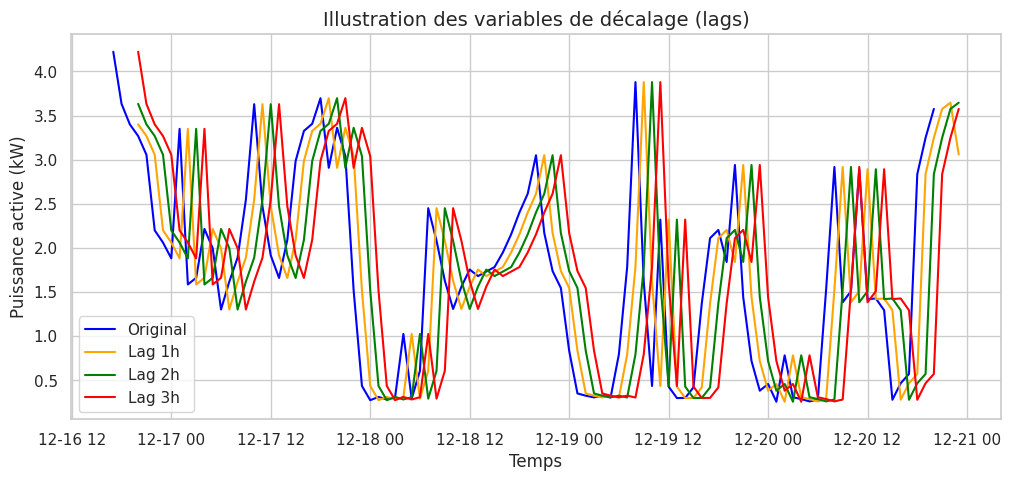

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

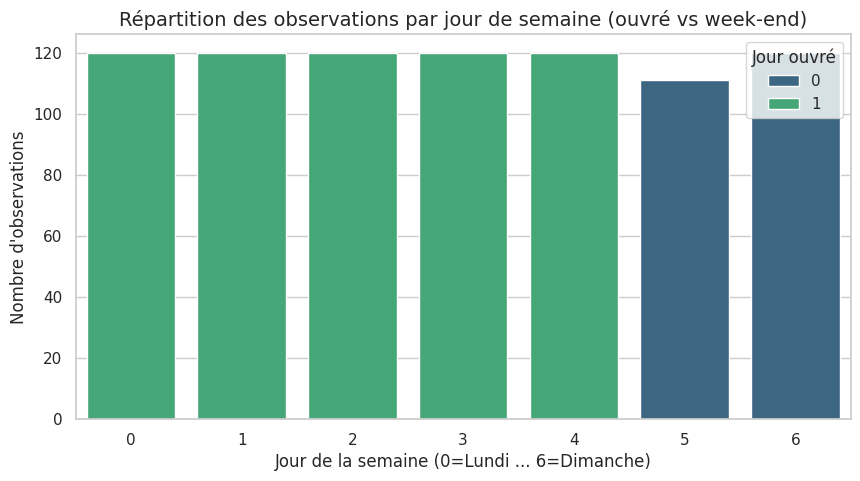

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

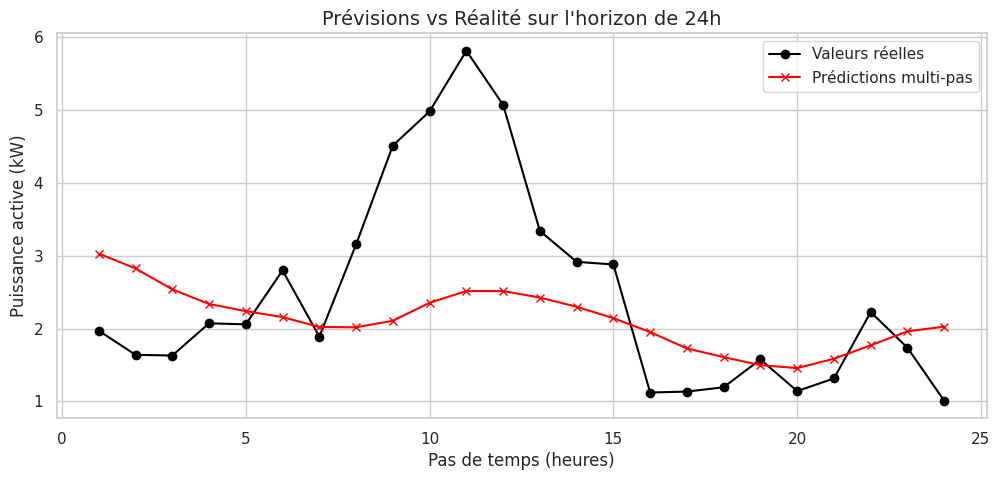

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

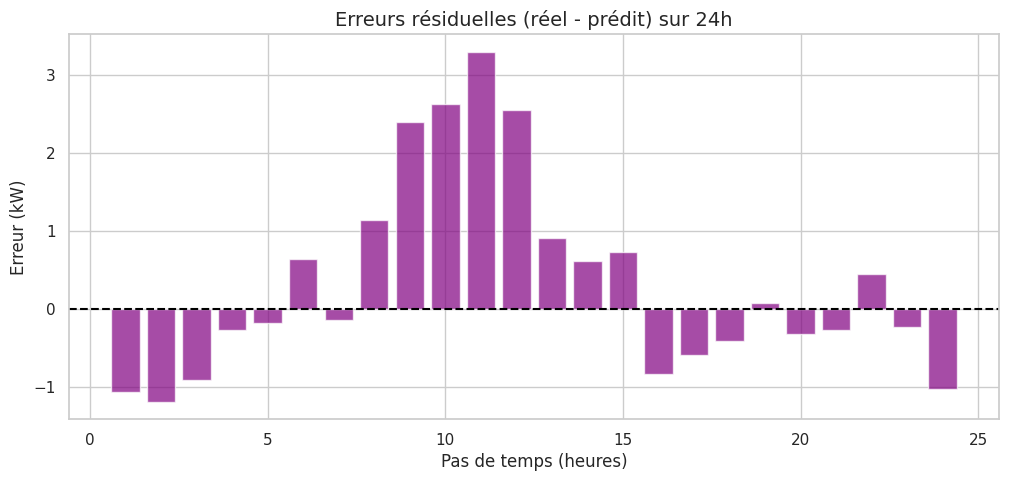

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- VISUEL 1 : Exemple des variables de décalage (Lags) ---
plt.figure(figsize=(12,5))
plt.plot(df_horaire.index[:100], df_horaire['Global_active_power'][:100], label="Original", color="blue")
plt.plot(df_multi_pas.index[:100], df_multi_pas['Lag_1'][:100], label="Lag 1h", color="orange")
plt.plot(df_multi_pas.index[:100], df_multi_pas['Lag_2'][:100], label="Lag 2h", color="green")
plt.plot(df_multi_pas.index[:100], df_multi_pas['Lag_3'][:100], label="Lag 3h", color="red")
plt.title("Illustration des variables de décalage (lags)")
plt.xlabel("Temps")
plt.ylabel("Puissance active (kW)")
plt.legend()
plt.show()


# --- VISUEL 2 : Distribution des variables calendaires ---
plt.figure(figsize=(10,5))
sns.countplot(x="Jour_Semaine", hue="Est_Ouvre", data=df_multi_pas, palette="viridis")
plt.title("Répartition des observations par jour de semaine (ouvré vs week-end)")
plt.xlabel("Jour de la semaine (0=Lundi ... 6=Dimanche)")
plt.ylabel("Nombre d'observations")
plt.legend(title="Jour ouvré")
plt.show()


# --- VISUEL 3 : Comparaison des prédictions vs valeurs réelles sur 24h ---
plt.figure(figsize=(12,5))
plt.plot(range(1, HORIZON_PREVISION+1), valeurs_reelles_24h, label="Valeurs réelles", color="black", marker="o")
plt.plot(range(1, HORIZON_PREVISION+1), sequence_predite, label="Prédictions multi-pas", color="red", marker="x")
plt.title("Prévisions vs Réalité sur l'horizon de 24h")
plt.xlabel("Pas de temps (heures)")
plt.ylabel("Puissance active (kW)")
plt.legend()
plt.grid(True)
plt.show()


# --- VISUEL 4 : Erreurs résiduelles sur 24h ---
plt.figure(figsize=(12,5))
erreurs = valeurs_reelles_24h - sequence_predite
plt.bar(range(1, HORIZON_PREVISION+1), erreurs, color="purple", alpha=0.7)
plt.axhline(0, color="black", linestyle="--")
plt.title("Erreurs résiduelles (réel - prédit) sur 24h")
plt.xlabel("Pas de temps (heures)")
plt.ylabel("Erreur (kW)")
plt.show()


Explication de l'architecture logicielle :GridSearch (Isolation Forest) : En faisant varier n_estimators, le code ajuste la finesse des frontières de décision. Maximiser le score moyen permet d'isoler la structure de partitionnement la plus stable face au bruit inhérent du réseau électrique.Direct Multi-step : Contrairement à un modèle récursif (qui réinjecterait une prédiction potentiellement fausse de t+1 pour calculer t+2), cette méthode élimine l'accumulation d'erreurs en entraînant des fonctions mathématiques structurellement indépendantes pour chaque heure de la journée à venir.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

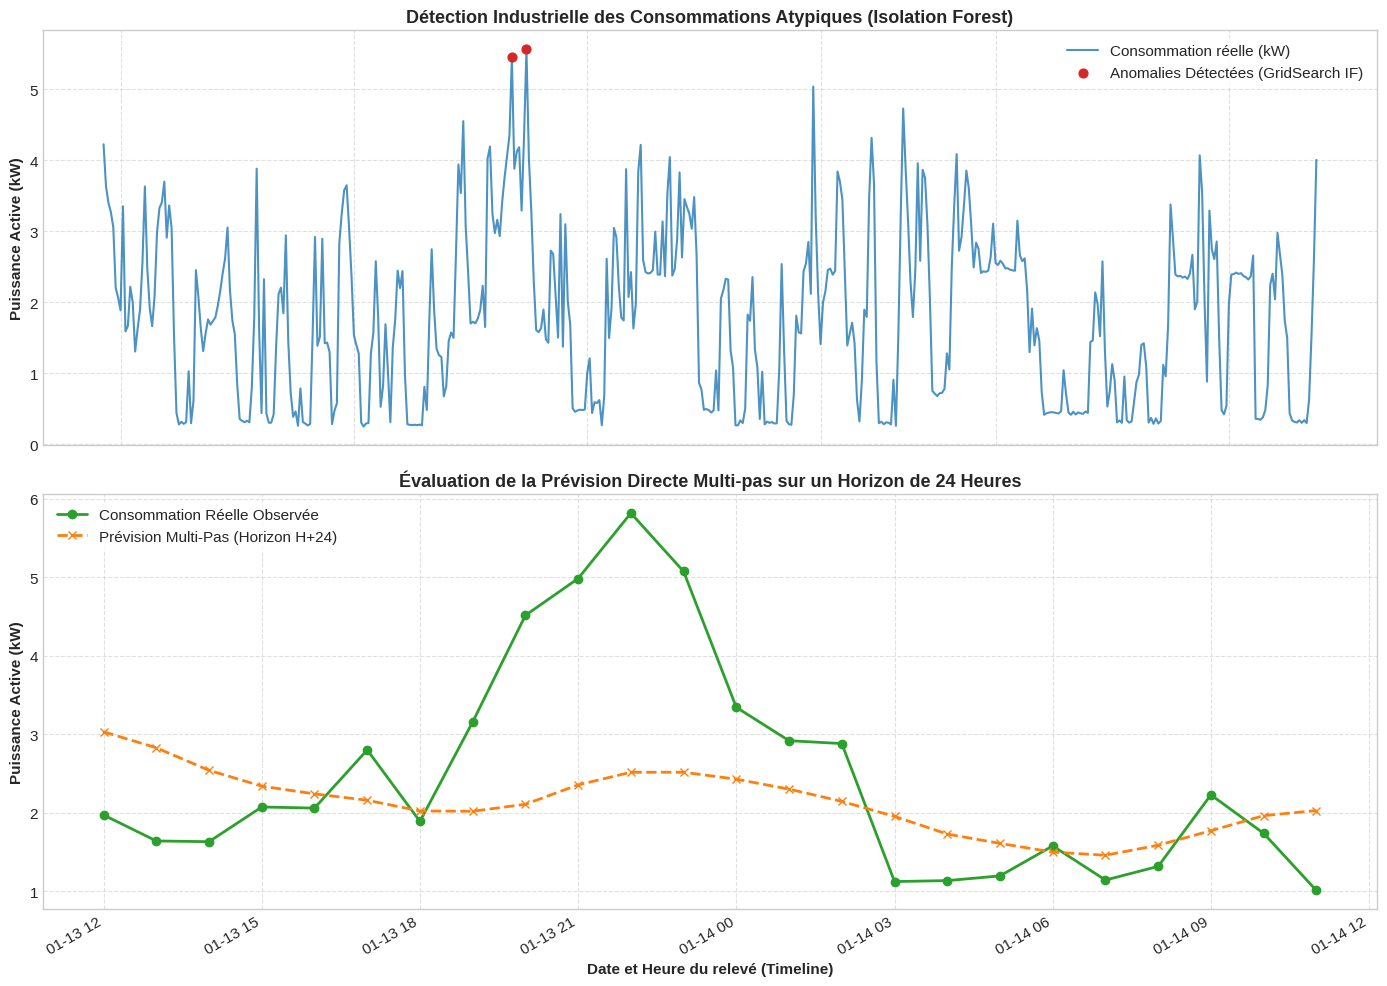

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt

# Configuration esthétique globale pour des graphiques clairs et lisibles
plt.style.use('seaborn-v0_8-whitegrid') # Style de grille épuré
plt.rcParams['figure.figsize'] = (14, 10) # Dimensions par défaut des figures
plt.rcParams['font.size'] = 11            # Taille globale de la police

# Création d'une figure composée de 2 sous-graphiques superposés (Subplots)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=False)

# =========================================================================
# GRAPHIC 1 : Consommation Globale et Visualisation des Anomalies Optimisées
# =========================================================================

# 1. Sélection d'une fenêtre temporelle lisible (Ex: les 500 premières heures)
df_visu_anomalies = df_horaire.iloc[:500]

# 2. Tracé de la courbe de consommation électrique réelle (Puissance active)
ax1.plot(df_visu_anomalies.index, df_visu_anomalies['Global_active_power'],
         color='#1f77b4', label='Consommation réelle (kW)', alpha=0.8, linewidth=1.5)

# 3. Extraction et superposition des points qualifiés d'anomalies par Isolation Forest
points_anomalies = df_visu_anomalies[df_visu_anomalies['Anomalie_Optimisee'] == 1]
ax1.scatter(points_anomalies.index, points_anomalies['Global_active_power'],
            color='#d62728', label='Anomalies Détectées (GridSearch IF)', s=40, zorder=3)

# 4. Habillage du premier graphique (Titres, légendes et axes)
ax1.set_title("Détection Industrielle des Consommations Atypiques (Isolation Forest)", fontsize=13, fontweight='bold')
ax1.set_ylabel("Puissance Active (kW)", fontweight='bold')
ax1.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
ax1.grid(True, linestyle='--', alpha=0.6)

# =========================================================================
# GRAPHIC 2 : Zoom sur la Prévision Multi-pas à Horizon H+24
# =========================================================================

# 1. Création d'un index temporel pour les 24 heures de l'horizon de test
index_24h = Y_global.iloc[index_coupure : index_coupure + HORIZON_PREVISION].index

# 2. Tracé de la consommation réelle observée sur cette journée cible
ax2.plot(index_24h, valeurs_reelles_24h,
         color='#2ca02c', label='Consommation Réelle Observée', marker='o', linewidth=2)

# 3. Tracé de la courbe prédictive générée par nos 24 modèles indépendants (Direct Multi-step)
ax2.plot(index_24h, sequence_predite,
         color='#ff7f0e', label='Prévision Multi-Pas (Horizon H+24)', linestyle='--', marker='x', linewidth=2)

# 4. Habillage du second graphique (Titres, légendes et axes)
ax2.set_title("Évaluation de la Prévision Directe Multi-pas sur un Horizon de 24 Heures", fontsize=13, fontweight='bold')
ax2.set_xlabel("Date et Heure du relevé (Timeline)", fontweight='bold')
ax2.set_ylabel("Puissance Active (kW)", fontweight='bold')
ax2.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
ax2.grid(True, linestyle='--', alpha=0.6)

# Rotation des étiquettes de date pour éviter les chevauchements visuels
plt.gcf().autofmt_xdate()

# Ajustement automatique des marges pour éliminer les espaces perdus
plt.tight_layout()

# Affichage final des graphiques à l'écran
plt.show()
